---
## 1.SETUP INICIAL

### 1.1 Librerías

In [53]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
from PIL import Image
from tqdm.notebook import tqdm

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import ParameterGrid, cross_val_score, train_test_split, learning_curve
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, auc, silhouette_score
    )

from sklearn.metrics.pairwise import euclidean_distances 
from sklearn.multiclass import OneVsRestClassifier

---
## 2.CARGA Y EXPLORACIÓN DE DATOS

### 2.1 Obtener datos

In [54]:
# Generar datos solo si no existen
from LHC import experiment_CMS

if not os.path.exists("CERN_dataset.zip") and not os.path.exists("CERN_datos"):
    print("Generando dataset CERN...")
    experiment_CMS(num_img=500, size=64, zip_name="CERN_dataset")
    print("Dataset generado exitosamente.")
else:
    print("Dataset ya existe. Saltando generación.")

Dataset ya existe. Saltando generación.


### 2.2 Cargar datos

In [55]:
def cargar_datos(zip_path="CERN_dataset.zip", carpeta_salida="CERN_datos", num_por_carpeta=100):
    #1. Proceso para descomprimir el archivo ZIP
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(carpeta_salida)
    X = []
    y = []
    #2. Recorrer las carpetas con las imagenes
    for clase in os.listdir(carpeta_salida):
        clase_path = os.path.join(carpeta_salida, clase)
        if os.path.isdir(clase_path):
            img_names = os.listdir(clase_path)
            if num_por_carpeta is not None:
                img_names = img_names[:num_por_carpeta]
            for img_name in tqdm(img_names, desc=f"Cargando {clase}"):
                img_path = os.path.join(clase_path, img_name)

                # 3. Procedimiento para cargar imagenes en escala de grises
                img = Image.open(img_path).convert("L")
                X.append(np.array(img))
                y.append(clase)  # etiqueta = nombre de la carpeta

    X = np.array(X)
    return X, y

X, y = cargar_datos("CERN_dataset.zip", num_por_carpeta=100)  
print(f"Se cargaron {len(X)} imágenes.")
print(f"Clases encontradas: {set(y)}")
print("Dimensiones de las imágenes:", X.shape)

Cargando electron:   0%|          | 0/100 [00:00<?, ?it/s]

Cargando muon:   0%|          | 0/100 [00:00<?, ?it/s]

Cargando neutrino:   0%|          | 0/100 [00:00<?, ?it/s]

Cargando proton:   0%|          | 0/100 [00:00<?, ?it/s]

Cargando quark:   0%|          | 0/100 [00:00<?, ?it/s]

Cargando tau:   0%|          | 0/100 [00:00<?, ?it/s]

Se cargaron 600 imágenes.
Clases encontradas: {'electron', 'neutrino', 'tau', 'quark', 'muon', 'proton'}
Dimensiones de las imágenes: (600, 64, 64)


### 2.3 Exploración visual

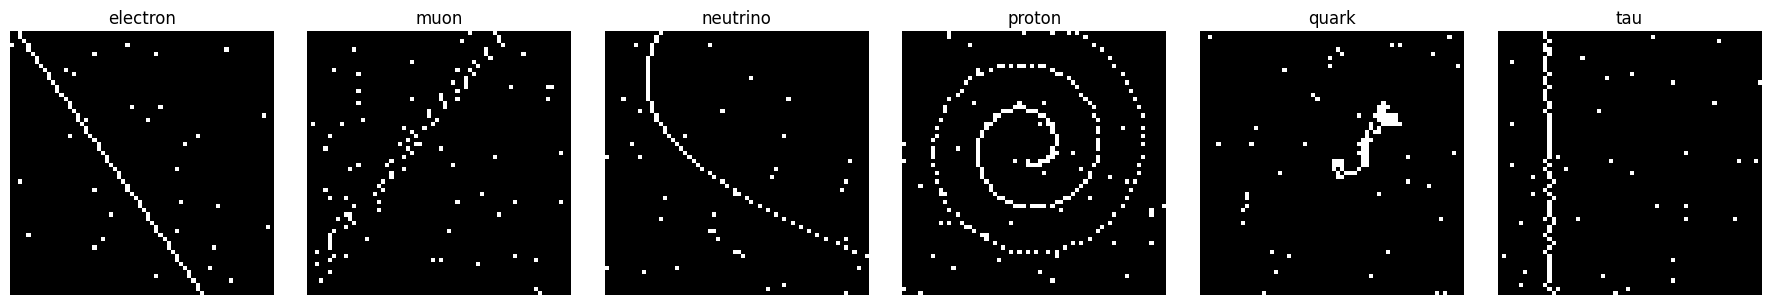

In [56]:
# Mostrar una imagen de cada clase
clases = sorted(list(set(y)))
fig, axs = plt.subplots(1, len(clases), figsize=(3*len(clases), 3))
for i, clase in enumerate(clases):
    idxs = [j for j, label in enumerate(y) if label == clase]
    idx = random.choice(idxs)  # índice aleatorio de la clase
    axs[i].imshow(X[idx], cmap='gray')
    axs[i].set_title(clase)
    axs[i].axis('off')
plt.tight_layout()
plt.show()

---
## 3. PREPROCESAMIENTO

### 3.1 Aplanar imágenes

In [57]:
print('Shape original:', X.shape)
X_flat = X.reshape(X.shape[0], -1)
print('Shape aplanado:', X_flat.shape)

Shape original: (600, 64, 64)
Shape aplanado: (600, 4096)


### 3.2 División Train/Test

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42, stratify=y)

### 3.3 Escalado (StandardScaler)

In [59]:
# Escalado de datos (fit solo en train, transform en test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Shape escalado train:', X_train_scaled.shape)
print('Shape escalado test:', X_test_scaled.shape)

Shape escalado train: (480, 4096)
Shape escalado test: (120, 4096)


### 3.4 Análisis PCA exploratorio

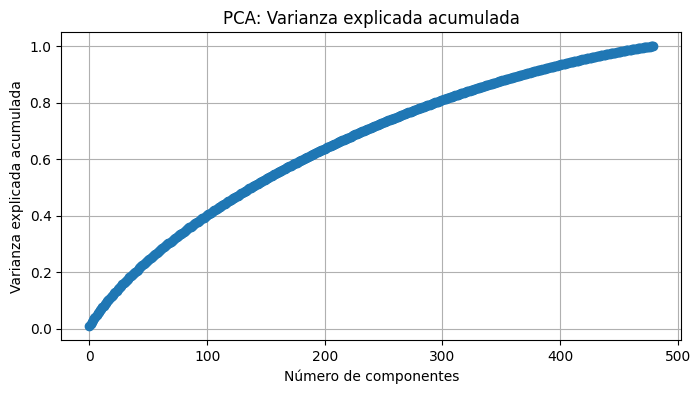

Componentes necesarios para 25% varianza: 53


In [60]:
# Análisis exploratorio de PCA
pca = PCA()
pca.fit(X_train_scaled)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,4))
plt.plot(varianza_acumulada, marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA: Varianza explicada acumulada')
plt.grid(True)
plt.show()
n_opt = np.argmax(varianza_acumulada >= 0.25) + 1
print(f'Componentes necesarios para 25% varianza: {n_opt}')

Evaluando impacto de reducción de dimensionalidad...



Variando % varianza:   0%|          | 0/6 [00:00<?, ?it/s]


IMPACTO DE LA REDUCCIÓN DE DIMENSIONALIDAD
 varianza_%  n_componentes  acc_train  acc_test     diff
       25.0             53   0.743750  0.566667 0.177083
       50.0            139   0.912500  0.575000 0.337500
       75.0            263   0.995833  0.575000 0.420833
       90.0            370   1.000000  0.550000 0.450000
       95.0            417   1.000000  0.575000 0.425000
       99.0            464   1.000000  0.575000 0.425000


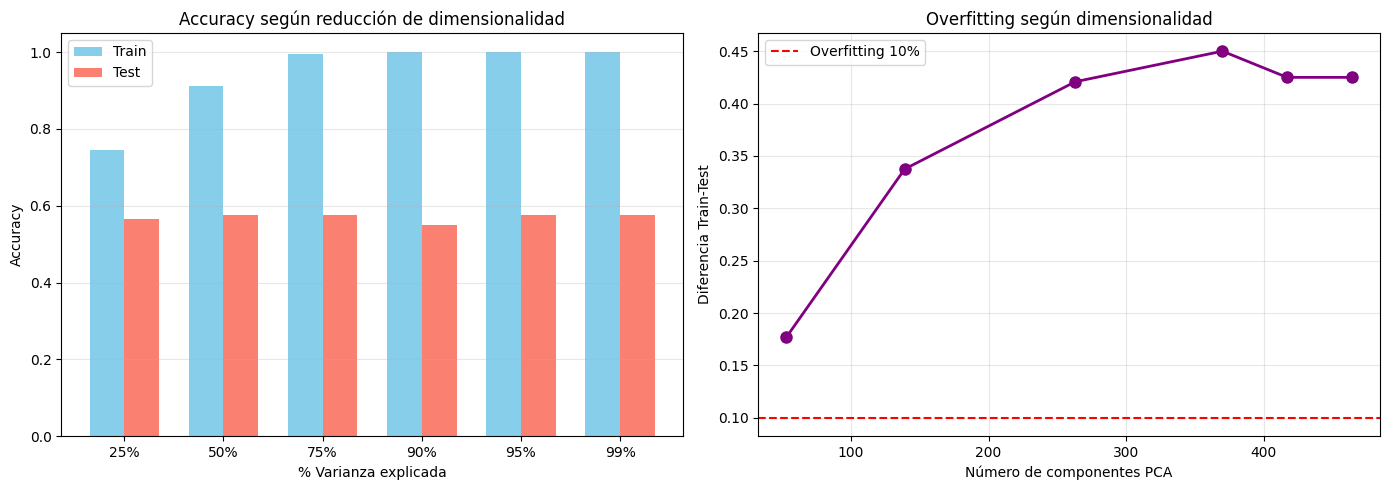


💡 Mejor balance (menor overfitting): 25% varianza
   → 53 componentes
   → Test accuracy: 0.5667
   → Diferencia: 0.1771


In [61]:
# Análisis del impacto de reducción de dimensionalidad
# Evaluar accuracy en test variando el % de varianza explicada


varianzas_pct = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
resultados_dim = []

print("Evaluando impacto de reducción de dimensionalidad...\n")
for var_pct in tqdm(varianzas_pct, desc="Variando % varianza"):
    # Pipeline simple con PCA + LogReg
    pipe_test = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=var_pct)),
        ('clf', LR(C=0.01, penalty='l2', solver='saga', max_iter=3000, random_state=42))
    ])
    
    # Entrenar
    pipe_test.fit(X_train, y_train)
    
    # Evaluar
    y_pred_test = pipe_test.predict(X_test)
    y_pred_train = pipe_test.predict(X_train)
    
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    n_components = pipe_test.named_steps['pca'].n_components_
    
    resultados_dim.append({
        'varianza_%': var_pct * 100,
        'n_componentes': n_components,
        'acc_train': acc_train,
        'acc_test': acc_test,
        'diff': acc_train - acc_test
    })

# Crear DataFrame de resultados
df_dim = pd.DataFrame(resultados_dim)
print("\n" + "="*70)
print("IMPACTO DE LA REDUCCIÓN DE DIMENSIONALIDAD")
print("="*70)
print(df_dim.to_string(index=False))
print("="*70)

# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Accuracy train vs test
x = np.arange(len(df_dim))
width = 0.35
axes[0].bar(x - width/2, df_dim['acc_train'], width, label='Train', color='skyblue')
axes[0].bar(x + width/2, df_dim['acc_test'], width, label='Test', color='salmon')
axes[0].set_xlabel('% Varianza explicada')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy según reducción de dimensionalidad')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{int(v)}%" for v in df_dim['varianza_%']])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Subplot 2: Número de componentes vs diferencia train-test
axes[1].plot(df_dim['n_componentes'], df_dim['diff'], 'o-', color='purple', linewidth=2, markersize=8)
axes[1].axhline(y=0.10, color='red', linestyle='--', label='Overfitting 10%')
axes[1].set_xlabel('Número de componentes PCA')
axes[1].set_ylabel('Diferencia Train-Test')
axes[1].set_title('Overfitting según dimensionalidad')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Mejor balance (menor overfitting): {df_dim.loc[df_dim['diff'].idxmin(), 'varianza_%']:.0f}% varianza")
print(f"   → {df_dim.loc[df_dim['diff'].idxmin(), 'n_componentes']:.0f} componentes")
print(f"   → Test accuracy: {df_dim.loc[df_dim['diff'].idxmin(), 'acc_test']:.4f}")
print(f"   → Diferencia: {df_dim.loc[df_dim['diff'].idxmin(), 'diff']:.4f}")

---
## 4. MODELOS DE MACHINE LEARNING

### FUNCIÓN AUXILIAR: Evaluar Overfitting

In [62]:
def evaluar_overfitting(model, X_train, X_test, y_train, y_test, model_name):
    """
    Evalúa overfitting comparando métricas de train y test y grafica resultados.
    """
    # Predicciones
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    # Métricas
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    # Diferencias
    acc_diff = train_acc - test_acc
    f1_diff = train_f1 - test_f1
    print(f"\n{'='*50}")
    print(f"Evaluación de Overfitting: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy Train: {train_acc:.4f} | Test: {test_acc:.4f} | Diff: {acc_diff:.4f}")
    print(f"F1-Score Train: {train_f1:.4f} | Test: {test_f1:.4f} | Diff: {f1_diff:.4f}")
    if acc_diff > 0.1:
        print("OVERFITTING (diferencia >10%)")
    elif acc_diff < 0.05:
        print("Buen balance entre train y test")
    else:
        print("Posible overfitting leve")
    # Gráfica comparativa
    metrics = ['Accuracy', 'F1-Score']
    train_scores = [train_acc, train_f1]
    test_scores = [test_acc, test_f1]
    x = np.arange(len(metrics))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, train_scores, width, label='Train', color='skyblue')
    ax.bar(x + width/2, test_scores, width, label='Test', color='salmon')
    ax.set_ylabel('Score')
    ax.set_title(f'Train vs Test - {model_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.set_ylim([0, 1])
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

---
### 4.1 REGRESIÓN LOGÍSTICA

#### 4.1.1 Hiperparámetros manuales

In [63]:
logreg_C = 0.01  
logreg_penalty = 'l2'
logreg_solver = 'saga' 

#### 4.1.2 Pipeline + Entrenamiento

In [64]:
# Pipeline y entrenamiento de regresión logística
pipe_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', LogisticRegression(C=logreg_C, penalty=logreg_penalty, solver=logreg_solver, max_iter=10000, random_state=42))
])
pipe_logreg.fit(X_train, y_train)

# Validación cruzada (CV) - usa el mismo criterio de 50% de varianza
pipe_logreg_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', LogisticRegression(C=logreg_C, penalty=logreg_penalty, solver=logreg_solver, max_iter=10000, random_state=42))
])
cv_scores = cross_val_score(pipe_logreg_cv, X_train, y_train, cv=5, scoring='accuracy')
print(f'Accuracy CV (5 folds): {cv_scores.mean():.4f}')

# Pipelines adicionales para comparación de curvas de aprendizaje
pipe_logreg_25 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.25)),
    ('clf', LogisticRegression(C=logreg_C, penalty=logreg_penalty, solver=logreg_solver, max_iter=10000, random_state=42))
])

pipe_logreg_95 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('clf', LogisticRegression(C=logreg_C, penalty=logreg_penalty, solver=logreg_solver, max_iter=10000, random_state=42))
])

pipe_logreg_99 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.99)),
    ('clf', LogisticRegression(C=logreg_C, penalty=logreg_penalty, solver=logreg_solver, max_iter=10000, random_state=42))
])

Accuracy CV (5 folds): 0.5792


#### 4.1.3 Evaluación completa

In [65]:
# Evaluación completa de regresión logística (solo métricas)
y_pred = pipe_logreg.predict(X_test)
y_train_pred = pipe_logreg.predict(X_train)

acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train, y_train_pred)

print(f'Accuracy en train: {acc_train:.4f}')
print(f'Accuracy en test: {acc_test:.4f}')
print(f'Accuracy CV (5 folds): {cv_scores.mean():.4f}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred))

Accuracy en train: 0.9125
Accuracy en test: 0.5750
Accuracy CV (5 folds): 0.5792

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.26      0.25      0.26        20
        muon       0.36      0.20      0.26        20
    neutrino       0.38      0.45      0.41        20
      proton       0.95      1.00      0.98        20
       quark       0.83      0.95      0.88        20
         tau       0.55      0.60      0.57        20

    accuracy                           0.57       120
   macro avg       0.55      0.57      0.56       120
weighted avg       0.55      0.57      0.56       120



#### 4.1.4 Matriz de confusión

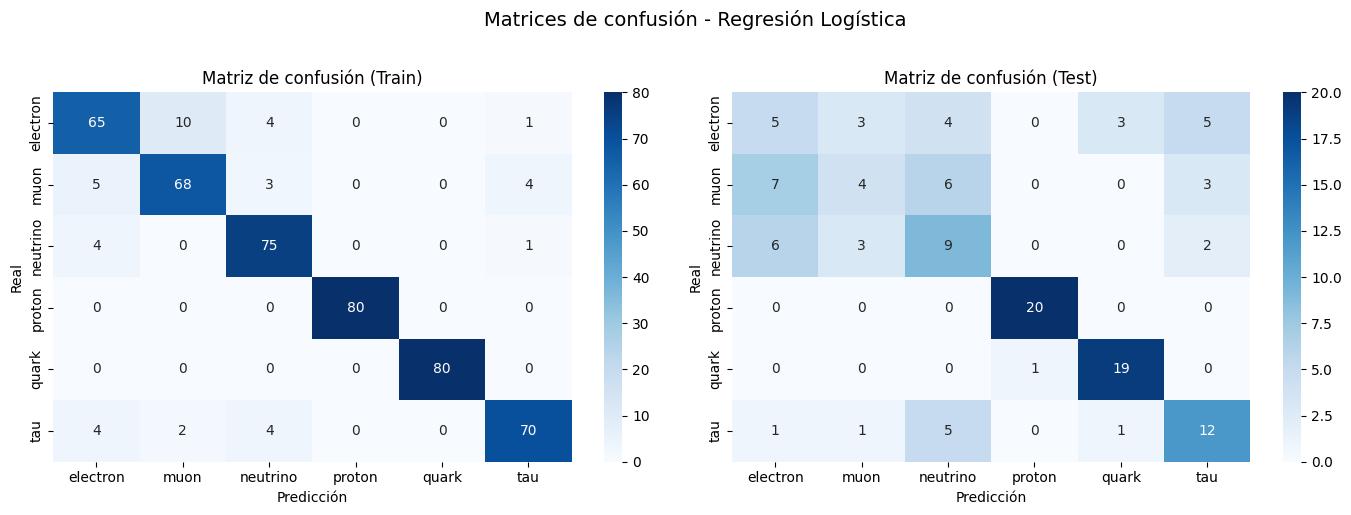

In [66]:
# Matriz de confusión - LogReg (Train y Test juntas)
cm_train = confusion_matrix(y_train, y_train_pred, labels=pipe_logreg.classes_)
cm_test = confusion_matrix(y_test, y_pred, labels=pipe_logreg.classes_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión Train
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=pipe_logreg.classes_, yticklabels=pipe_logreg.classes_, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# Matriz de confusión Test
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=pipe_logreg.classes_, yticklabels=pipe_logreg.classes_, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

plt.suptitle('Matrices de confusión - Regresión Logística', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 4.1.5 Curva de aprendizaje

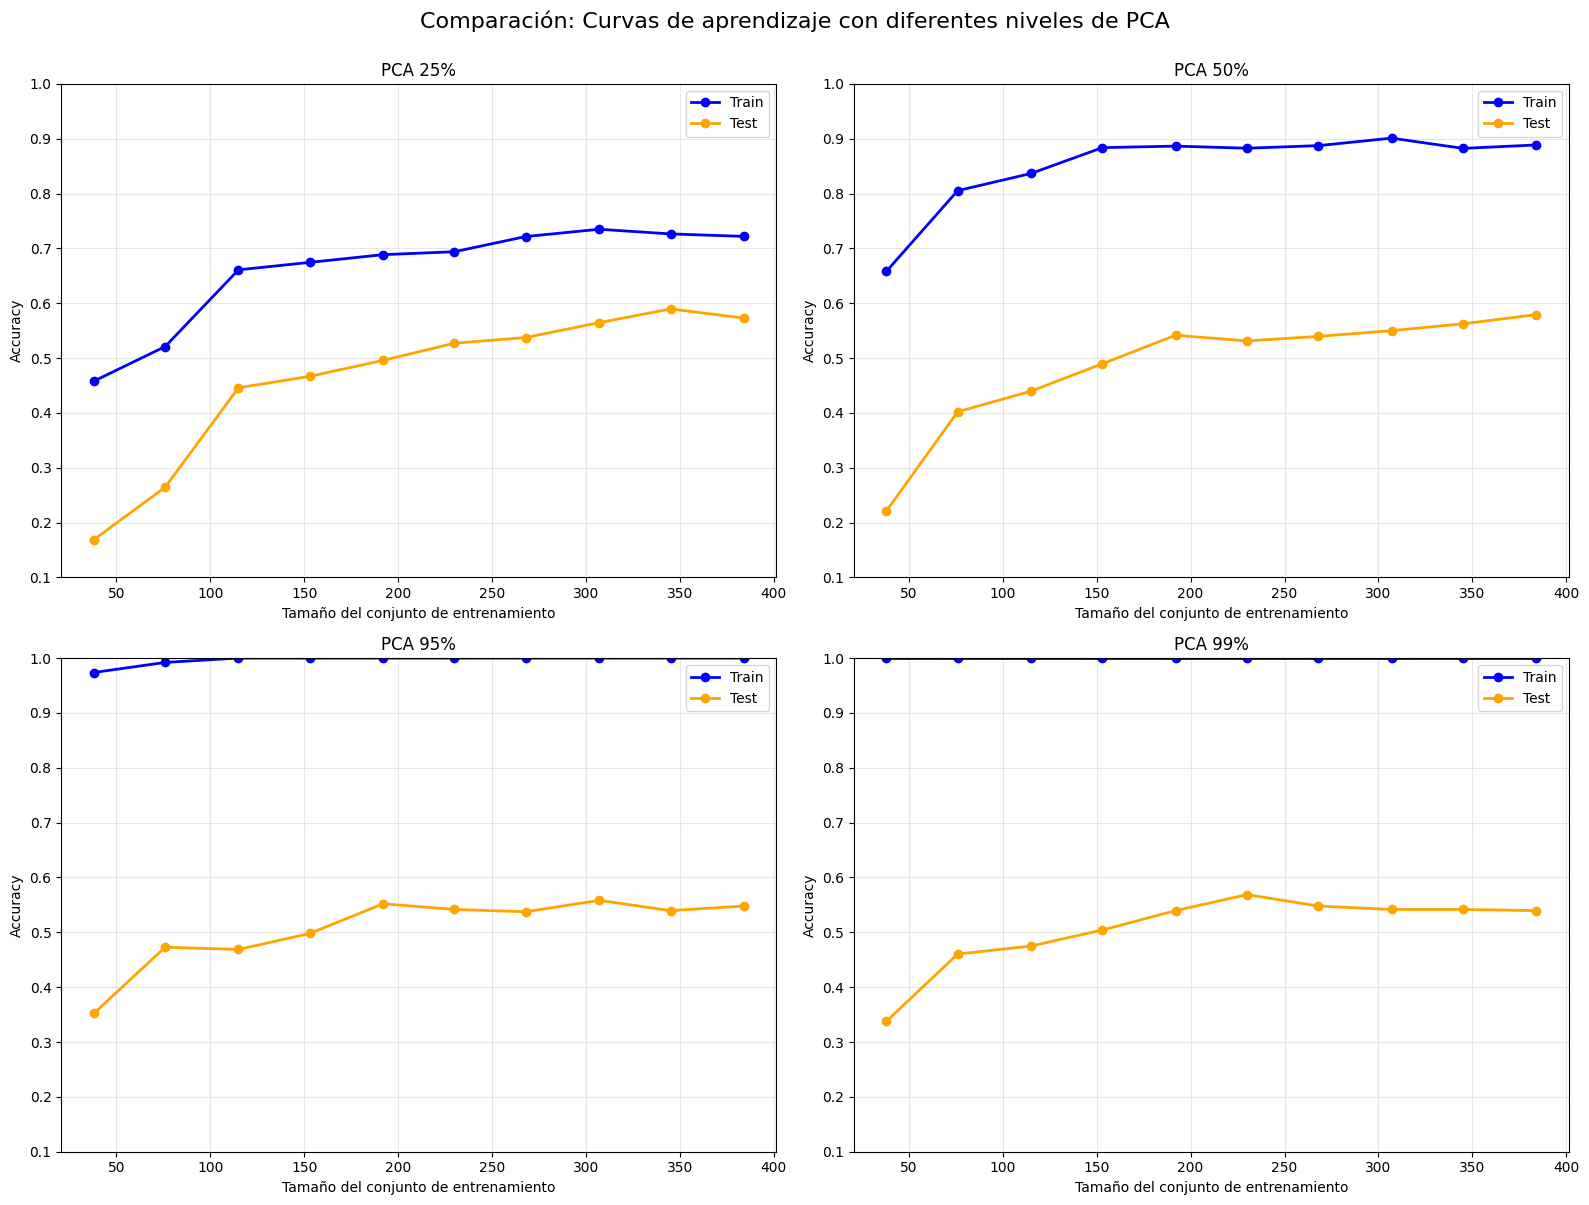

In [67]:
# Curva de aprendizaje comparativa: PCA 50%, 25%, 95%, 99%

# Calcular curvas con PCA 50% (actual)
train_sizes_50, train_scores_50, test_scores_50 = learning_curve(
    pipe_logreg_cv, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

# Calcular curvas con PCA 25%
train_sizes_25, train_scores_25, test_scores_25 = learning_curve(
    pipe_logreg_25, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

# Calcular curvas con PCA 95%
train_sizes_95, train_scores_95, test_scores_95 = learning_curve(
    pipe_logreg_95, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

# Calcular curvas con PCA 99%
train_sizes_99, train_scores_99, test_scores_99 = learning_curve(
    pipe_logreg_99, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

train_mean_50 = train_scores_50.mean(axis=1)
test_mean_50 = test_scores_50.mean(axis=1)
train_mean_25 = train_scores_25.mean(axis=1)
test_mean_25 = test_scores_25.mean(axis=1)
train_mean_95 = train_scores_95.mean(axis=1)
test_mean_95 = test_scores_95.mean(axis=1)
train_mean_99 = train_scores_99.mean(axis=1)
test_mean_99 = test_scores_99.mean(axis=1)

# Gráfico comparativo 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: PCA 25%
axes[0, 0].plot(train_sizes_25, train_mean_25, 'o-', label='Train', color='blue', linewidth=2)
axes[0, 0].plot(train_sizes_25, test_mean_25, 'o-', label='Test', color='orange', linewidth=2)
axes[0, 0].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('PCA 25%')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0.1, 1.0])

# Subplot 2: PCA 50%
axes[0, 1].plot(train_sizes_50, train_mean_50, 'o-', label='Train', color='blue', linewidth=2)
axes[0, 1].plot(train_sizes_50, test_mean_50, 'o-', label='Test', color='orange', linewidth=2)
axes[0, 1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('PCA 50%')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.1, 1.0])

# Subplot 3: PCA 95%
axes[1, 0].plot(train_sizes_95, train_mean_95, 'o-', label='Train', color='blue', linewidth=2)
axes[1, 0].plot(train_sizes_95, test_mean_95, 'o-', label='Test', color='orange', linewidth=2)
axes[1, 0].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('PCA 95%')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0.1, 1.0])

# Subplot 4: PCA 99%
axes[1, 1].plot(train_sizes_99, train_mean_99, 'o-', label='Train', color='blue', linewidth=2)
axes[1, 1].plot(train_sizes_99, test_mean_99, 'o-', label='Test', color='orange', linewidth=2)
axes[1, 1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('PCA 99%')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0.1, 1.0])

plt.suptitle('Comparación: Curvas de aprendizaje con diferentes niveles de PCA', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

#### 4.1.6 Curvas ROC-AUC

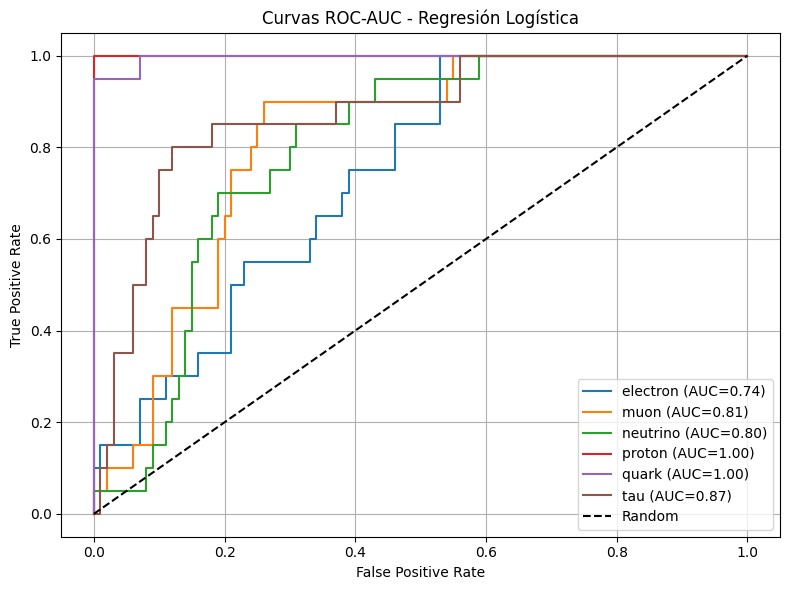

In [68]:
# Curvas ROC-AUC - LogReg
y_test_bin = label_binarize(y_test, classes=pipe_logreg.classes_)
y_score = pipe_logreg.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(pipe_logreg.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, clase in enumerate(pipe_logreg.classes_):
    plt.plot(fpr[i], tpr[i], label=f'{clase} (AUC={roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC-AUC - Regresión Logística')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.1.7 Análisis de overfitting


Evaluación de Overfitting: Regresión Logística
Accuracy Train: 0.9125 | Test: 0.5750 | Diff: 0.3375
F1-Score Train: 0.9123 | Test: 0.5591 | Diff: 0.3533
OVERFITTING (diferencia >10%)


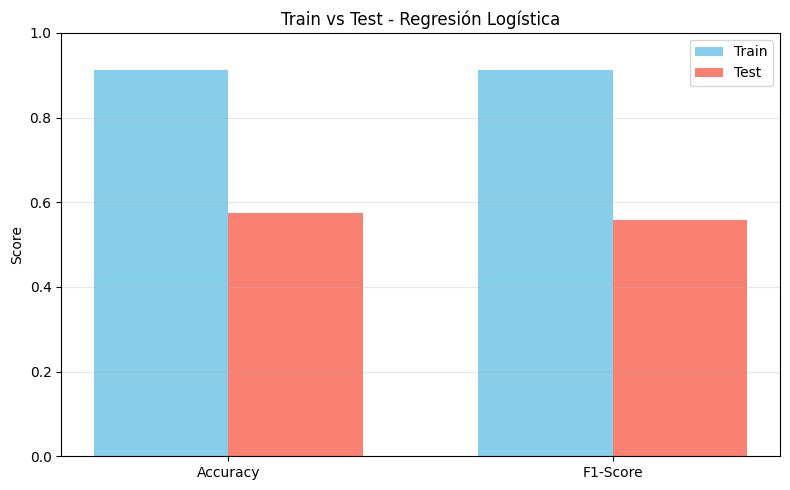

In [69]:
# Análisis de overfitting - LogReg
evaluar_overfitting(pipe_logreg, X_train, X_test, y_train, y_test, "Regresión Logística")

---
### 4.2 SVM (RBF Kernel)

#### 4.2.1 Hiperparámetros manuales

In [70]:
svm_C = 10
svm_gamma = 'scale'

#### 4.2.2 Pipeline + Entrenamiento

In [71]:
# Pipeline y entrenamiento de SVM RBF
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', SVC(C=svm_C, gamma=svm_gamma, kernel='rbf', random_state=42, probability=True))
])
pipe_svm.fit(X_train, y_train)

# Validación cruzada (CV)
pipe_svm_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', SVC(C=svm_C, gamma=svm_gamma, kernel='rbf', random_state=42, probability=True))
])
cv_scores_svm = cross_val_score(pipe_svm_cv, X_train, y_train, cv=5, scoring='accuracy')
print(f'Accuracy CV (5 folds): {cv_scores_svm.mean():.4f}')

Accuracy CV (5 folds): 0.3917


#### 4.2.3 Evaluación completa

In [72]:
# Evaluación completa de SVM RBF
y_pred_svm = pipe_svm.predict(X_test)
y_train_pred_svm = pipe_svm.predict(X_train)

acc_test_svm = accuracy_score(y_test, y_pred_svm)
acc_train_svm = accuracy_score(y_train, y_train_pred_svm)

print(f'Accuracy en train: {acc_train_svm:.4f}')
print(f'Accuracy en test: {acc_test_svm:.4f}')
print(f'Accuracy CV (5 folds): {cv_scores_svm.mean():.4f}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_svm))

Accuracy en train: 1.0000
Accuracy en test: 0.4000
Accuracy CV (5 folds): 0.3917

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.32      0.40      0.36        20
        muon       0.33      0.35      0.34        20
    neutrino       0.29      0.75      0.42        20
      proton       0.00      0.00      0.00        20
       quark       1.00      0.90      0.95        20
         tau       0.00      0.00      0.00        20

    accuracy                           0.40       120
   macro avg       0.32      0.40      0.34       120
weighted avg       0.32      0.40      0.34       120



c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

#### 4.2.4 Matriz de confusión

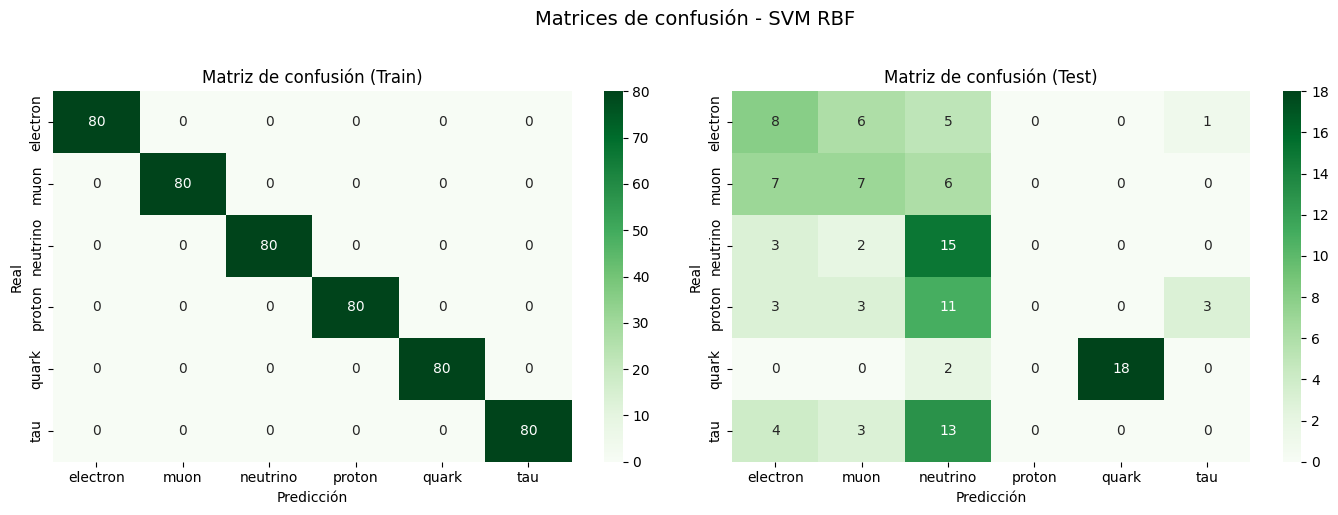

In [73]:
# Matriz de confusión - SVM RBF (Train y Test juntas)
cm_train_svm = confusion_matrix(y_train, y_train_pred_svm, labels=pipe_svm.classes_)
cm_test_svm = confusion_matrix(y_test, y_pred_svm, labels=pipe_svm.classes_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión Train
sns.heatmap(cm_train_svm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=pipe_svm.classes_, yticklabels=pipe_svm.classes_, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# Matriz de confusión Test
sns.heatmap(cm_test_svm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=pipe_svm.classes_, yticklabels=pipe_svm.classes_, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

plt.suptitle('Matrices de confusión - SVM RBF', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 4.2.5 Curva de aprendizaje

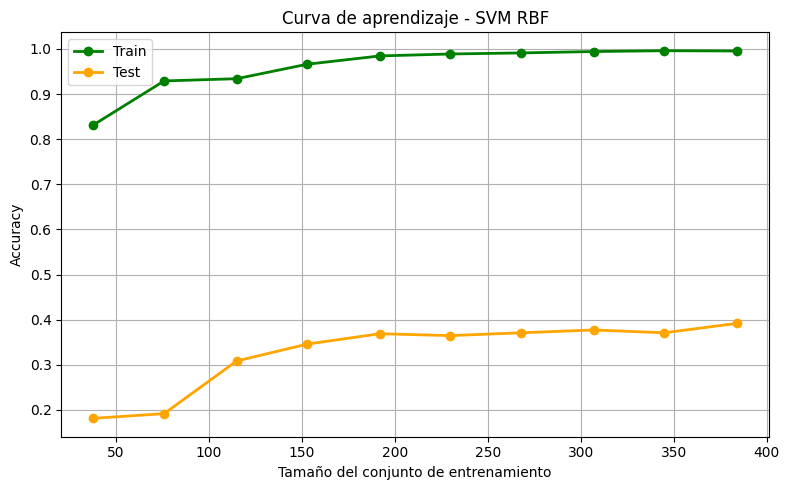

In [74]:
# Curva de aprendizaje - SVM RBF
train_sizes_svm, train_scores_svm, test_scores_svm = learning_curve(
    pipe_svm_cv, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

train_mean_svm = train_scores_svm.mean(axis=1)
test_mean_svm = test_scores_svm.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_svm, train_mean_svm, 'o-', label='Train', color='green', linewidth=2)
plt.plot(train_sizes_svm, test_mean_svm, 'o-', label='Test', color='orange', linewidth=2)
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curva de aprendizaje - SVM RBF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.2.6 Curvas ROC-AUC

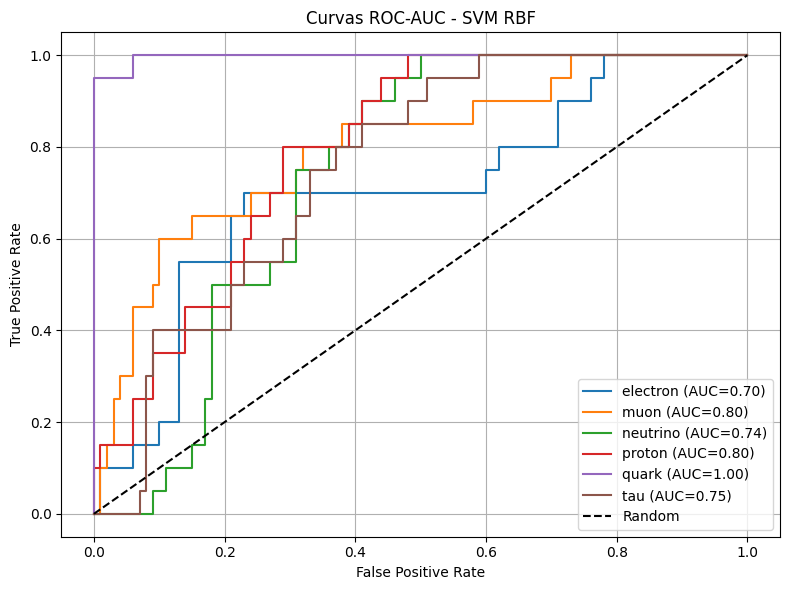

In [75]:
# Curvas ROC-AUC - SVM RBF
y_test_bin_svm = label_binarize(y_test, classes=pipe_svm.classes_)
y_score_svm = pipe_svm.predict_proba(X_test)

fpr_svm = dict()
tpr_svm = dict()
roc_auc_svm = dict()

for i in range(len(pipe_svm.classes_)):
    fpr_svm[i], tpr_svm[i], _ = roc_curve(y_test_bin_svm[:, i], y_score_svm[:, i])
    roc_auc_svm[i] = auc(fpr_svm[i], tpr_svm[i])

plt.figure(figsize=(8, 6))
for i, clase in enumerate(pipe_svm.classes_):
    plt.plot(fpr_svm[i], tpr_svm[i], label=f'{clase} (AUC={roc_auc_svm[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC-AUC - SVM RBF')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.2.7 Análisis de overfitting


Evaluación de Overfitting: SVM RBF
Accuracy Train: 1.0000 | Test: 0.4000 | Diff: 0.6000
F1-Score Train: 1.0000 | Test: 0.3435 | Diff: 0.6565
OVERFITTING (diferencia >10%)


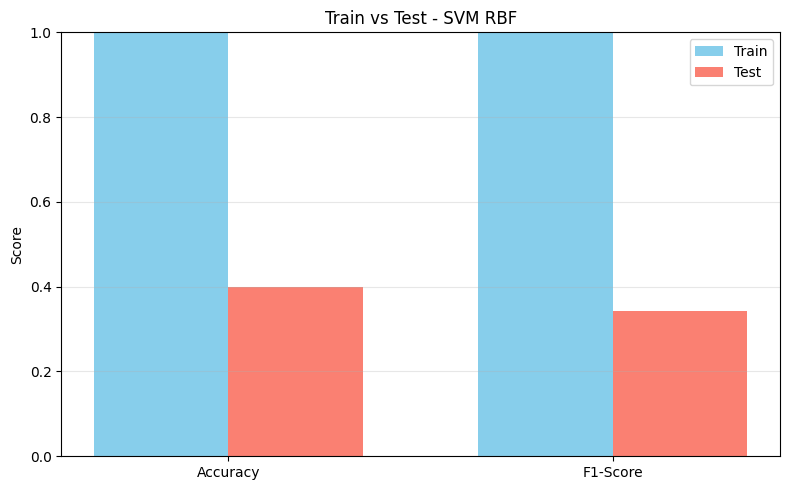

In [76]:
# Análisis de overfitting - SVM RBF
evaluar_overfitting(pipe_svm, X_train, X_test, y_train, y_test, "SVM RBF")

---
### 4.3 K-NEAREST NEIGHBORS (KNN)

#### 4.3.1 Hiperparámetros manuales

In [77]:
n_neighbors = 5  # k = 5
weights = 'uniform'
metric = 'euclidean'

#### 4.3.2 Pipeline + Entrenamiento

In [78]:
# Pipeline y entrenamiento de KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric))
])
pipe_knn.fit(X_train, y_train)

# Validación cruzada (CV)
pipe_knn_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric))
])
cv_scores_knn = cross_val_score(pipe_knn_cv, X_train, y_train, cv=5, scoring='accuracy')
print(f'Accuracy CV (5 folds): {cv_scores_knn.mean():.4f}')

# Pipelines adicionales para comparación de curvas de aprendizaje
pipe_knn_25 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.25)),
    ('clf', KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric))
])

pipe_knn_95 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('clf', KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric))
])

pipe_knn_99 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.99)),
    ('clf', KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric))
])

Accuracy CV (5 folds): 0.3292


#### 4.3.3 Evaluación completa

In [79]:
y_pred = pipe_knn.predict(X_test)
y_train_pred = pipe_knn.predict(X_train)


acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train, y_train_pred)

print(f'Accuracy en train: {acc_train:.4f}')
print(f'Accuracy en test: {acc_test:.4f}')
print(f'Accuracy CV (5 folds): {cv_scores_knn.mean():.4f}') 
print('\nReporte de clasificación:')

print(classification_report(y_test, y_pred))

Accuracy en train: 0.5062
Accuracy en test: 0.3083
Accuracy CV (5 folds): 0.3292

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.06      0.05      0.05        20
        muon       0.22      0.90      0.35        20
    neutrino       0.00      0.00      0.00        20
      proton       0.00      0.00      0.00        20
       quark       1.00      0.90      0.95        20
         tau       0.00      0.00      0.00        20

    accuracy                           0.31       120
   macro avg       0.21      0.31      0.22       120
weighted avg       0.21      0.31      0.22       120



c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

#### 4.3.4 Matrices de confusión

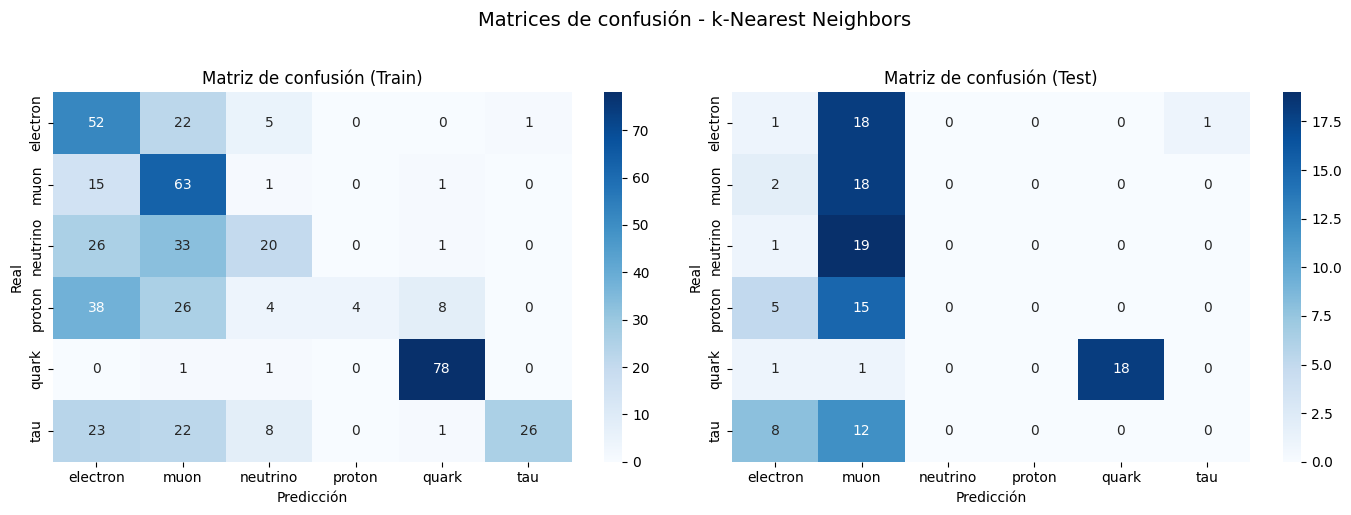

In [80]:
class_names = sorted(list(set(y))) 

# Matriz de confusión Train y Test
cm_train = confusion_matrix(y_train, y_train_pred, labels=class_names)
cm_test = confusion_matrix(y_test, y_pred, labels=class_names)

# Creamos la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz de confusión Train
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# 2. Matriz de confusión Test
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

# Título general actualizado
plt.suptitle('Matrices de confusión - k-Nearest Neighbors', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 4.3.5 Curva de aprendizaje

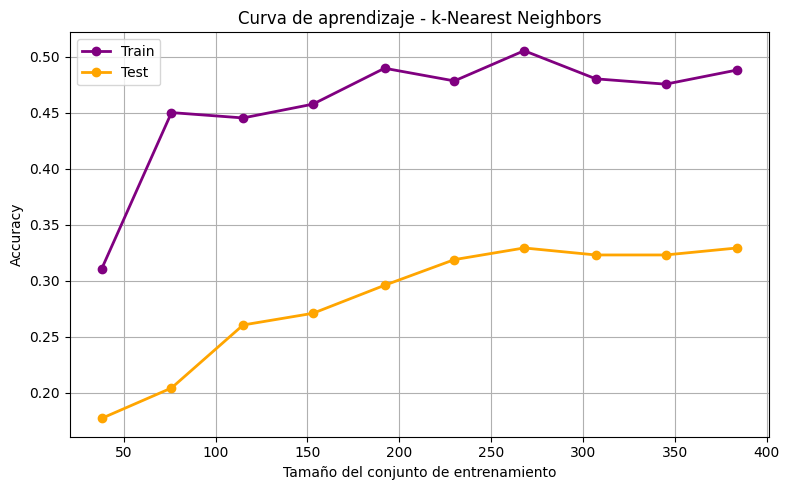

In [81]:
# Curva de aprendizaje
train_sizes_knn, train_scores_knn, test_scores_knn = learning_curve(
    pipe_knn_cv, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

train_mean_knn = train_scores_knn.mean(axis=1)
test_mean_knn = test_scores_knn.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_knn, train_mean_knn, 'o-', label='Train', color='purple', linewidth=2)
plt.plot(train_sizes_knn, test_mean_knn, 'o-', label='Test', color='orange', linewidth=2)
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curva de aprendizaje - k-Nearest Neighbors')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.3. 6 Curvas ROC - AUC

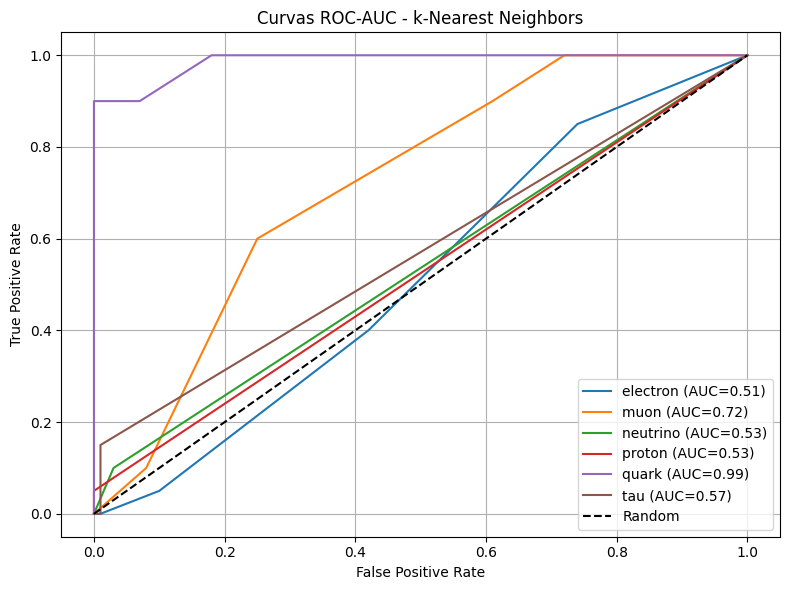

In [82]:
# Curvas ROC-AUC - KNN
y_test_bin_knn = label_binarize(y_test, classes=pipe_knn.classes_)
y_score_knn = pipe_knn.predict_proba(X_test)

fpr_knn = dict()
tpr_knn = dict()
roc_auc_knn = dict()
for i in range(len(pipe_knn.classes_)):
    fpr_knn[i], tpr_knn[i], _ = roc_curve(y_test_bin_knn[:, i], y_score_knn[:, i])
    roc_auc_knn[i] = auc(fpr_knn[i], tpr_knn[i])

plt.figure(figsize=(8, 6))
for i, clase in enumerate(pipe_knn.classes_):
    plt.plot(fpr_knn[i], tpr_knn[i], label=f'{clase} (AUC={roc_auc_knn[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC-AUC - k-Nearest Neighbors')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

---
### 4.4 NAIVE BAYES

#### 4.4.1 Hiperparámetros manuales

In [83]:
var_smoothing = 0.0001

#### 4.4.2 Pipeline + Entrenamiento

In [84]:
# Pipeline y entrenamiento de Naive Bayes
pipe_nb = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', GaussianNB(var_smoothing=var_smoothing))
])
pipe_nb.fit(X_train, y_train)

# Validación cruzada (CV)
pipe_nb_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', GaussianNB(var_smoothing=var_smoothing))
])
cv_scores_nb = cross_val_score(pipe_nb_cv, X_train, y_train, cv=5, scoring='accuracy')
print(f'Accuracy CV (5 folds): {cv_scores_nb.mean():.4f}')


Accuracy CV (5 folds): 0.1792


#### 4.4.3 Evaluación y métricas

In [85]:
y_pred_nb = pipe_nb.predict(X_test)
y_train_pred_nb = pipe_nb.predict(X_train)

# 2. Cálculo de Accuracy
acc_test = accuracy_score(y_test, y_pred_nb)
acc_train = accuracy_score(y_train, y_train_pred_nb)

# 3. Impresión de Métricas
print(f'Accuracy en train: {acc_train:.4f}')
print(f'Accuracy en test: {acc_test:.4f}')
print(f'Accuracy CV (5 folds): {cv_scores_nb.mean():.4f}') # Usa el resultado de la CV del código anterior
print('\nReporte de clasificación:')

# 4. Reporte de Clasificación
print(classification_report(y_test, y_pred))

Accuracy en train: 0.7188
Accuracy en test: 0.1833
Accuracy CV (5 folds): 0.1792

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.06      0.05      0.05        20
        muon       0.22      0.90      0.35        20
    neutrino       0.00      0.00      0.00        20
      proton       0.00      0.00      0.00        20
       quark       1.00      0.90      0.95        20
         tau       0.00      0.00      0.00        20

    accuracy                           0.31       120
   macro avg       0.21      0.31      0.22       120
weighted avg       0.21      0.31      0.22       120



c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

#### 4.4.4 Matriz de confusión

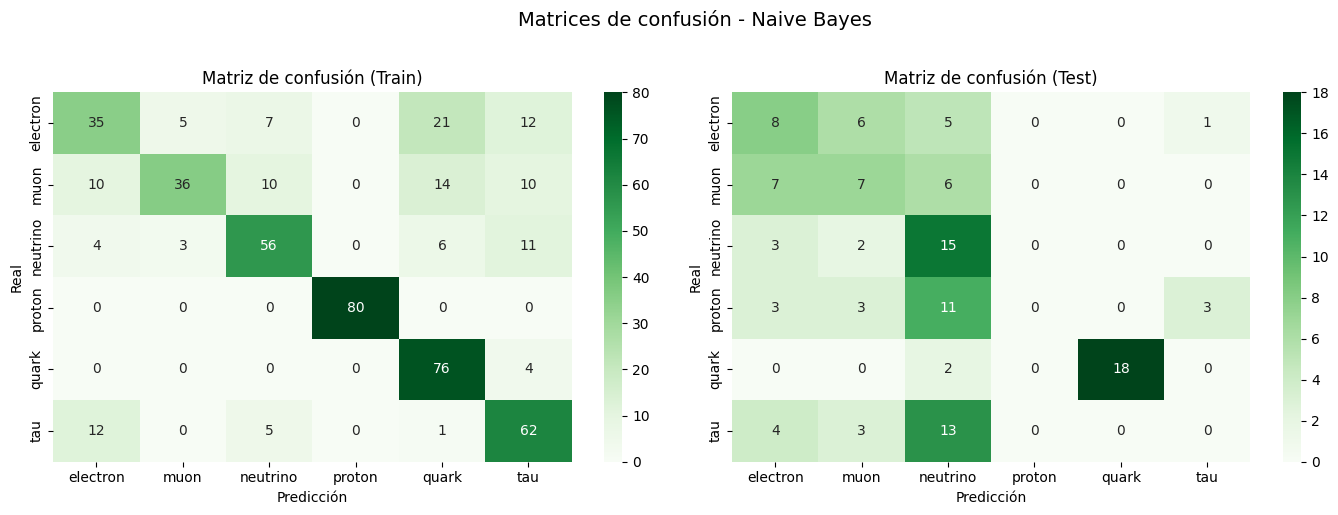

In [86]:
# Matriz de confusión - NAIVE BAYES (Train y Test juntas)
cm_train_nb = confusion_matrix(y_train, y_train_pred_nb, labels=pipe_nb.classes_)
cm_test_nb = confusion_matrix(y_test, y_pred_nb, labels=pipe_nb.classes_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión Train
sns.heatmap(cm_train_nb, annot=True, fmt='d', cmap='Greens', 
            xticklabels=pipe_nb.classes_, yticklabels=pipe_nb.classes_, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# Matriz de confusión Test
sns.heatmap(cm_test_svm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=pipe_svm.classes_, yticklabels=pipe_svm.classes_, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

plt.suptitle('Matrices de confusión - Naive Bayes', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 4.4.5 Curva de aprendizaje

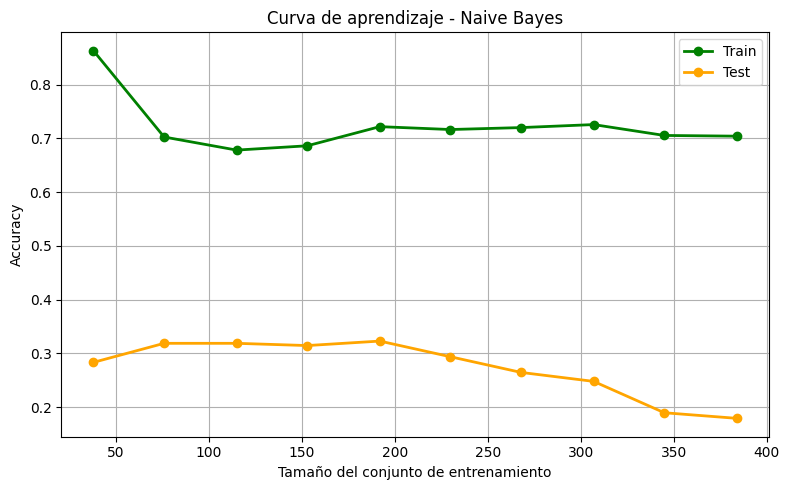

In [87]:
# Curva de aprendizaje - Naive Bayes
train_sizes_nb, train_scores_nb, test_scores_nb = learning_curve(
    pipe_nb_cv, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

train_mean_nb = train_scores_nb.mean(axis=1)
test_mean_nb = test_scores_nb.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_nb, train_mean_nb, 'o-', label='Train', color='green', linewidth=2)
plt.plot(train_sizes_nb, test_mean_nb, 'o-', label='Test', color='orange', linewidth=2)
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curva de aprendizaje - Naive Bayes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.4.6 Curvas ROC-AUC

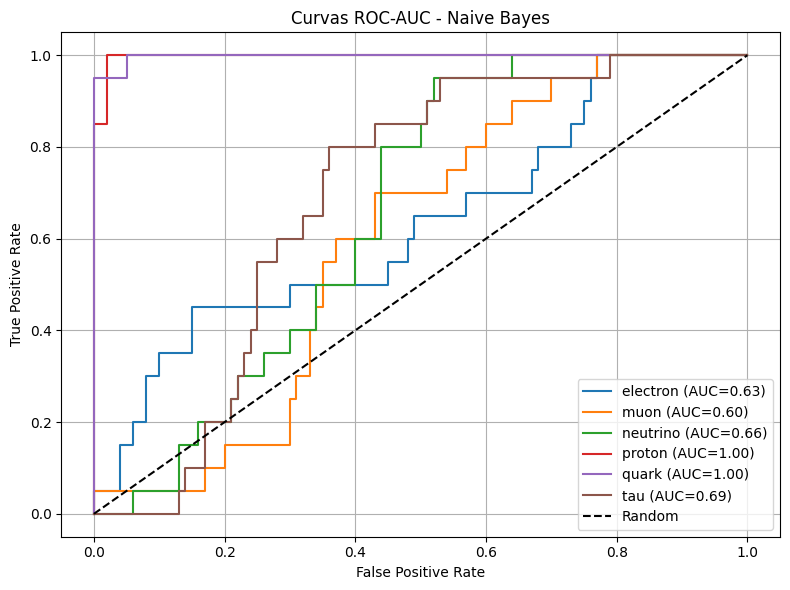

In [88]:
# Curvas ROC-AUC - Naive Bayes
y_test_bin_nb = label_binarize(y_test, classes=pipe_nb.classes_)
y_score_nb = pipe_nb.predict_proba(X_test)

fpr_nb = dict()
tpr_nb = dict()
roc_auc_nb = dict()
for i in range(len(pipe_nb.classes_)):
    fpr_nb[i], tpr_nb[i], _ = roc_curve(y_test_bin_nb[:, i], y_score_nb[:, i])
    roc_auc_nb[i] = auc(fpr_nb[i], tpr_nb[i])

plt.figure(figsize=(8, 6))
for i, clase in enumerate(pipe_nb.classes_):
    plt.plot(fpr_nb[i], tpr_nb[i], label=f'{clase} (AUC={roc_auc_nb[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC-AUC - Naive Bayes')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

---
### 4.5 ÁRBOL DE DECISIÓN

#### 4.5.1 Hiperparámetros manuales

In [89]:
DT_PARAMS = {
    'criterion': 'entropy',
    'max_depth': 30,
    'min_samples_split': 10,
    'min_samples_leaf': 4,
    'random_state': 42
}

#### 4.5.2 Pipeline y entrenamiento

In [90]:
# 1. Pipeline y entrenamiento de Árbol de Decisión (50% varianza)
# Este pipeline se usa para el entrenamiento inicial (pipe_dt.fit)
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', DecisionTreeClassifier(**DT_PARAMS)) 
])
pipe_dt.fit(X_train, y_train)

# 2. Validación cruzada (CV) - usa el mismo criterio de 50% de varianza
# Usamos pipe_dt_cv para calcular el score CV
pipe_dt_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', DecisionTreeClassifier(**DT_PARAMS))
])
cv_scores = cross_val_score(pipe_dt_cv, X_train, y_train, cv=5, scoring='accuracy') 
print(f'Accuracy CV (5 folds): {cv_scores.mean():.4f}')


Accuracy CV (5 folds): 0.4750


#### 4.5.3 Evaluación y métricas

In [91]:
y_pred_dt = pipe_dt.predict(X_test)
y_train_pred_dt = pipe_dt.predict(X_train)

# 2. Cálculo de Accuracy
acc_test = accuracy_score(y_test, y_pred_dt)
acc_train = accuracy_score(y_train, y_train_pred_dt)
# 3. Impresión de Métricas
print(f'Accuracy en train: {acc_train:.4f}')
print(f'Accuracy en test: {acc_test:.4f}')
print(f'Accuracy CV (5 folds): {cv_scores.mean():.4f}') # Usa el resultado de la CV del código anterior
print('\nReporte de clasificación:')

# 4. Reporte de Clasificación
print(classification_report(y_test, y_pred_dt))

Accuracy en train: 0.8979
Accuracy en test: 0.4750
Accuracy CV (5 folds): 0.4750

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.25      0.35      0.29        20
        muon       0.36      0.50      0.42        20
    neutrino       0.25      0.25      0.25        20
      proton       1.00      0.95      0.97        20
       quark       0.82      0.70      0.76        20
         tau       0.25      0.10      0.14        20

    accuracy                           0.47       120
   macro avg       0.49      0.48      0.47       120
weighted avg       0.49      0.47      0.47       120



#### 4.5.4 Matrices de confusión

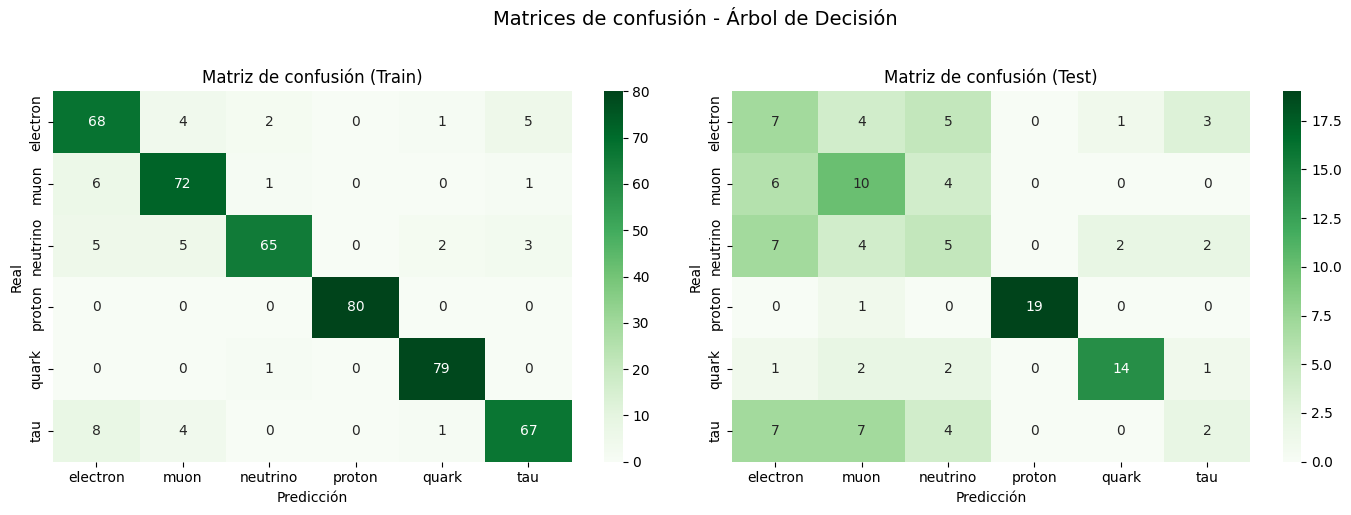

In [92]:
# Matriz de confusión - Árbol de Decisión (Train y Test juntas)
cm_train_dt = confusion_matrix(y_train, y_train_pred_dt, labels=pipe_dt.classes_)
cm_test_dt = confusion_matrix(y_test, y_pred_dt, labels=pipe_dt.classes_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión Train
sns.heatmap(cm_train_dt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=pipe_dt.classes_, yticklabels=pipe_dt.classes_, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# Matriz de confusión Test
sns.heatmap(cm_test_dt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=pipe_dt.classes_, yticklabels=pipe_dt.classes_, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

plt.suptitle('Matrices de confusión - Árbol de Decisión', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 4.5.5 Curva de aprendizaje

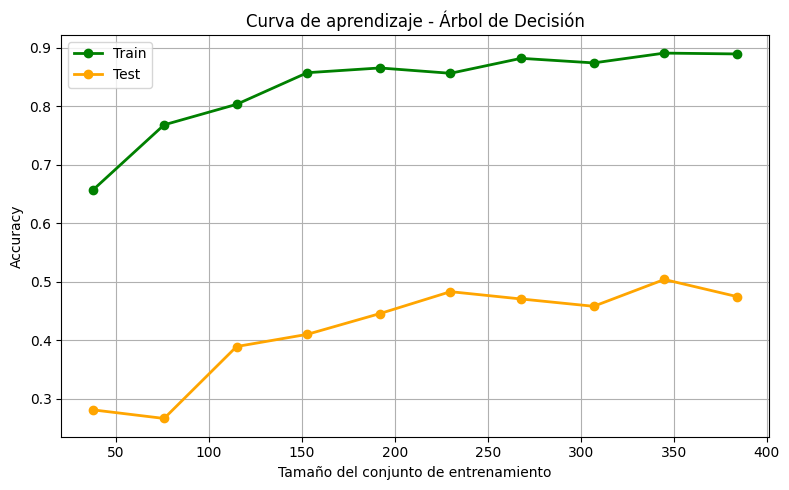

In [93]:
# Curva de aprendizaje - Árbol de Decisión
train_sizes_dt, train_scores_dt, test_scores_dt = learning_curve(
    pipe_dt, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

train_mean_dt = train_scores_dt.mean(axis=1)
test_mean_dt = test_scores_dt.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_dt, train_mean_dt, 'o-', label='Train', color='green', linewidth=2)
plt.plot(train_sizes_dt, test_mean_dt, 'o-', label='Test', color='orange', linewidth=2)
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curva de aprendizaje - Árbol de Decisión')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.5.6 Curvas ROC - AUC

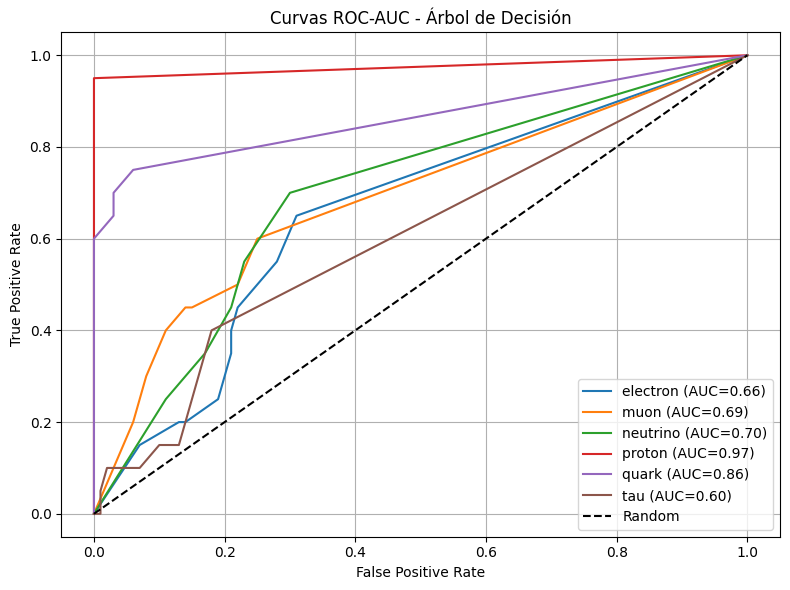

In [94]:
# Curvas ROC-AUC - Árbol de Decisión
y_test_bin_dt = label_binarize(y_test, classes=pipe_dt.classes_)
y_score_dt = pipe_dt.predict_proba(X_test)

fpr_dt = dict()
tpr_dt = dict()
roc_auc_dt = dict()
for i in range(len(pipe_dt.classes_)):
    fpr_dt[i], tpr_dt[i], _ = roc_curve(y_test_bin_dt[:, i], y_score_dt[:, i])
    roc_auc_dt[i] = auc(fpr_dt[i], tpr_dt[i])

plt.figure(figsize=(8, 6))
for i, clase in enumerate(pipe_dt.classes_):
    plt.plot(fpr_dt[i], tpr_dt[i], label=f'{clase} (AUC={roc_auc_dt[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC-AUC - Árbol de Decisión')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

---
### 4.6 RANDOM FOREST

#### 4.6.1 Hiperparámetros y Entrenamiento

In [95]:
RF_PARAMS = {
    'n_estimators': 100,
    'min_samples_split': 10,
    'min_samples_leaf': 2,
    'max_depth': None, 
    'random_state': 42
}

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', RandomForestClassifier(**RF_PARAMS)) 
])
pipe_rf.fit(X_train, y_train)

pipe_rf_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', RandomForestClassifier(**RF_PARAMS))
])
cv_scores_rf = cross_val_score(pipe_rf_cv, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1) 
print(f'Accuracy RF CV (5 folds, PCA 50%): {cv_scores_rf.mean():.4f}')

Accuracy RF CV (5 folds, PCA 50%): 0.5083


#### 4.6.2 Evaluación y Métricas

In [96]:
y_pred_rf = pipe_rf.predict(X_test)
y_train_pred_rf = pipe_rf.predict(X_train)

# 2. Cálculo de Accuracy
acc_test = accuracy_score(y_test, y_pred_rf)
acc_train = accuracy_score(y_train, y_train_pred_rf)
# 3. Impresión de Métricas
print(f'Accuracy en train: {acc_train:.4f}')
print(f'Accuracy en test: {acc_test:.4f}')
print(f'Accuracy CV (5 folds): {cv_scores_rf.mean():.4f}') 
print('\nReporte de clasificación:')

# 4. Reporte de Clasificación
print(classification_report(y_test, y_pred_rf))

Accuracy en train: 0.9979
Accuracy en test: 0.5667
Accuracy CV (5 folds): 0.5083

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.44      0.55      0.49        20
        muon       0.39      0.35      0.37        20
    neutrino       0.35      0.65      0.46        20
      proton       1.00      0.95      0.97        20
       quark       0.89      0.85      0.87        20
         tau       0.50      0.05      0.09        20

    accuracy                           0.57       120
   macro avg       0.60      0.57      0.54       120
weighted avg       0.60      0.57      0.54       120



#### 4.6.3 Matrices de confusión

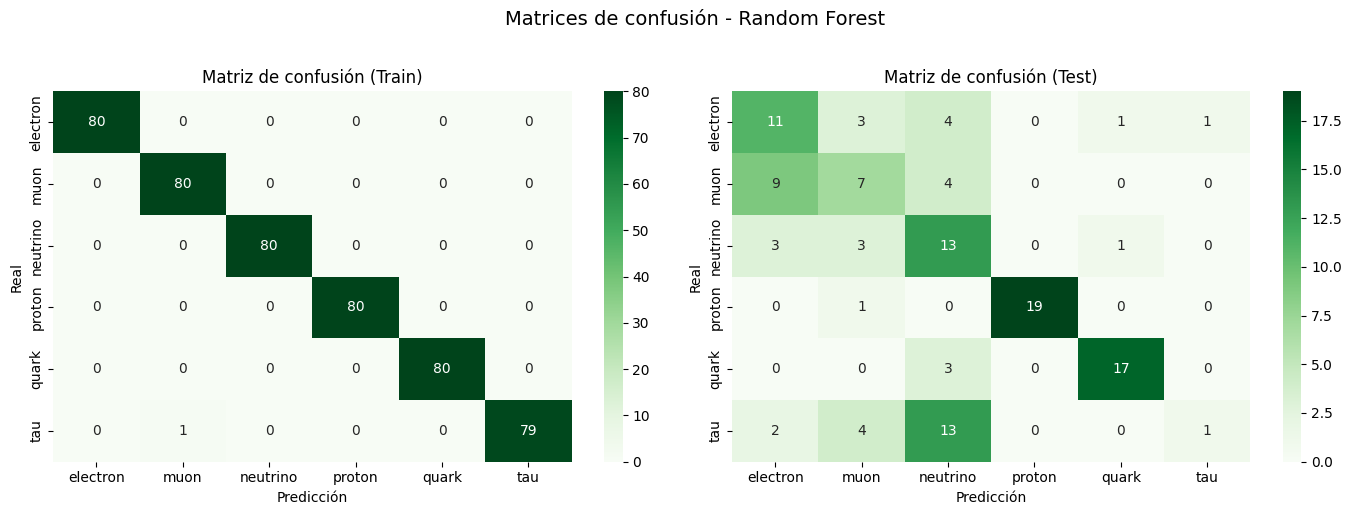

In [97]:
# Matriz de confusión - Random Forest (Train y Test juntas)
cm_train_rf = confusion_matrix(y_train, y_train_pred_rf, labels=pipe_rf.classes_)
cm_test_rf = confusion_matrix(y_test, y_pred_rf, labels=pipe_rf.classes_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión Train
sns.heatmap(cm_train_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=pipe_rf.classes_, yticklabels=pipe_rf.classes_, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# Matriz de confusión Test
sns.heatmap(cm_test_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=pipe_rf.classes_, yticklabels=pipe_rf.classes_, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

plt.suptitle('Matrices de confusión - Random Forest', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 4.6.4 Curva de aprendizaje

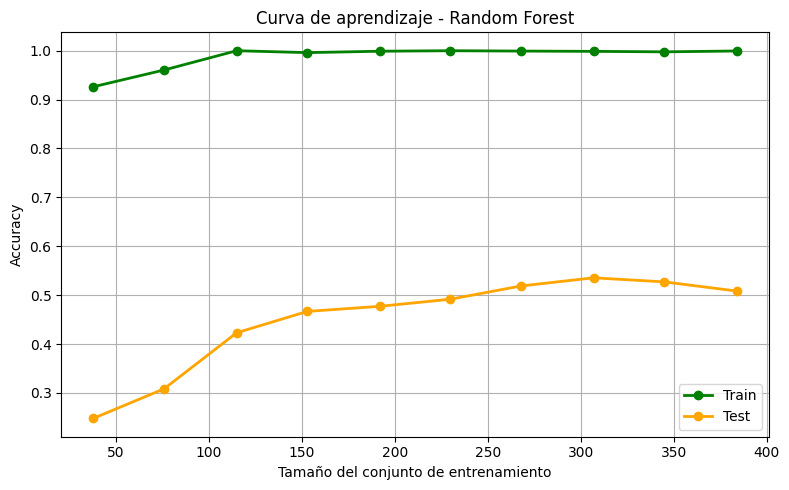

In [98]:
# Curva de aprendizaje - Random Forest
train_sizes_rf, train_scores_rf, test_scores_rf = learning_curve(
    pipe_rf, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

train_mean_rf = train_scores_rf.mean(axis=1)
test_mean_rf = test_scores_rf.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_rf, train_mean_rf, 'o-', label='Train', color='green', linewidth=2)
plt.plot(train_sizes_rf, test_mean_rf, 'o-', label='Test', color='orange', linewidth=2)
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curva de aprendizaje - Random Forest')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.6.5 Curvas ROC - AUC

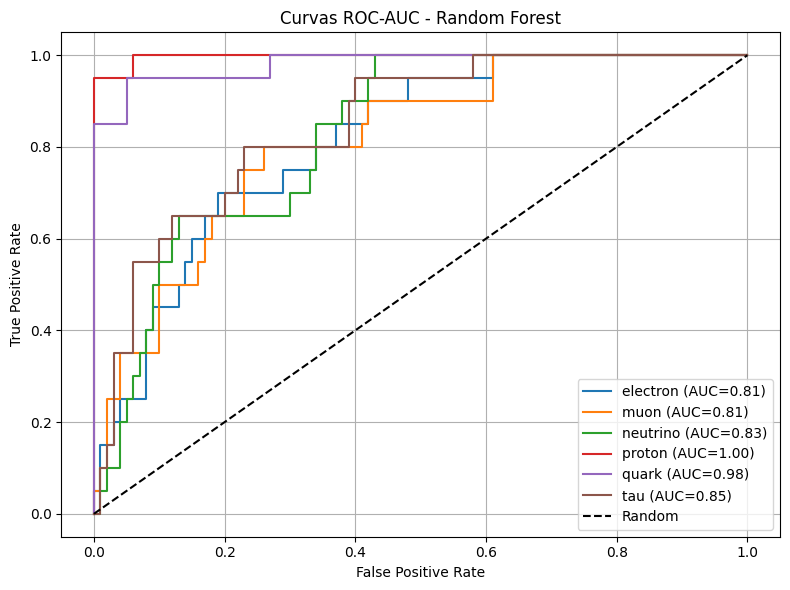

In [99]:
# Curvas ROC-AUC - Random Forest
y_test_bin_rf = label_binarize(y_test, classes=pipe_rf.classes_)
y_score_rf = pipe_rf.predict_proba(X_test)

fpr_rf = dict()
tpr_rf = dict()
roc_auc_rf = dict()
for i in range(len(pipe_rf.classes_)):
    fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test_bin_rf[:, i], y_score_rf[:, i])
    roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])

plt.figure(figsize=(8, 6))
for i, clase in enumerate(pipe_rf.classes_):
    plt.plot(fpr_rf[i], tpr_rf[i], label=f'{clase} (AUC={roc_auc_rf[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC-AUC - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

---
### 4.7 GRADIENT BOOSTING (Opcional)

#### 4.7.1 Entrenamiento

#### 4.7.2 Evaluación y Métricas

---
### 4.8 VOTING CLASSIFIER (Ensamble)

#### 4.8.1 Configuración y Entrenamiento

#### 4.8.2 Evaluación y Métricas

---
### 4.9 STACKING CLASSIFIER (Opcional)

#### 4.9.1 Configuración y Entrenamiento

#### 4.9.2 Evaluación y Métricas

---
### 4.10 PERCEPTRÓN (Opcional)

#### 4.10.1 Hiperparámetros manuales

In [100]:
perceptron_alpha = 0.0001  # Regularización L2
perceptron_max_iter = 1000
perceptron_tol = 1e-3

#### 4.10.2 Pipeline + Entrenamiento

In [101]:
# Pipeline y entrenamiento de Perceptron
pipe_perceptron = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', Perceptron(alpha=perceptron_alpha, max_iter=perceptron_max_iter, tol=perceptron_tol, random_state=42))
])
pipe_perceptron.fit(X_train, y_train)

# Validación cruzada (CV)
pipe_perceptron_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', Perceptron(alpha=perceptron_alpha, max_iter=perceptron_max_iter, tol=perceptron_tol, random_state=42))
])
cv_scores_perceptron = cross_val_score(pipe_perceptron_cv, X_train, y_train, cv=5, scoring='accuracy')
print(f'Accuracy CV (5 folds): {cv_scores_perceptron.mean():.4f}')

Accuracy CV (5 folds): 0.4625


#### 4.10.3 Evaluación y Métricas

In [102]:
# Evaluación completa de Perceptron
y_pred_perceptron = pipe_perceptron.predict(X_test)
y_train_pred_perceptron = pipe_perceptron.predict(X_train)

acc_test_perceptron = accuracy_score(y_test, y_pred_perceptron)
acc_train_perceptron = accuracy_score(y_train, y_train_pred_perceptron)

print(f'Accuracy en train: {acc_train_perceptron:.4f}')
print(f'Accuracy en test: {acc_test_perceptron:.4f}')
print(f'Accuracy CV (5 folds): {cv_scores_perceptron.mean():.4f}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_perceptron))


Accuracy en train: 0.7375
Accuracy en test: 0.4833
Accuracy CV (5 folds): 0.4625

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.31      0.20      0.24        20
        muon       0.27      0.15      0.19        20
    neutrino       0.29      0.25      0.27        20
      proton       0.56      1.00      0.71        20
       quark       0.79      0.95      0.86        20
         tau       0.37      0.35      0.36        20

    accuracy                           0.48       120
   macro avg       0.43      0.48      0.44       120
weighted avg       0.43      0.48      0.44       120



#### 4.10.4 Matrices de confusión

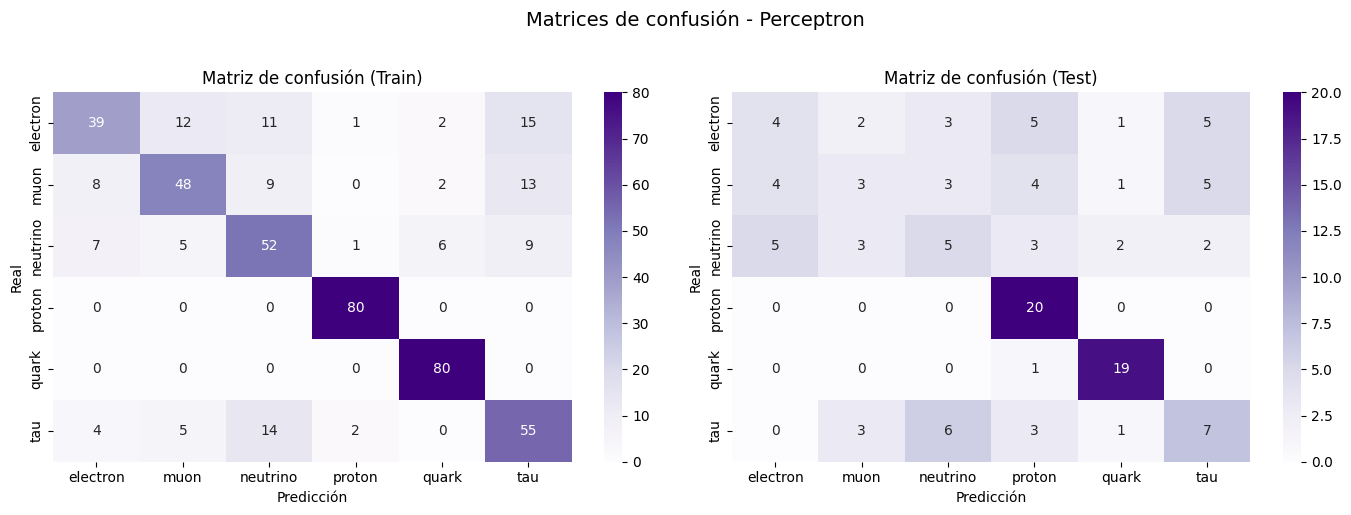

In [103]:
# Matriz de confusión
cm_train_perceptron = confusion_matrix(y_train, y_train_pred_perceptron, labels=pipe_perceptron.classes_)
cm_test_perceptron = confusion_matrix(y_test, y_pred_perceptron, labels=pipe_perceptron.classes_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión Train
sns.heatmap(cm_train_perceptron, annot=True, fmt='d', cmap='Purples', 
            xticklabels=pipe_perceptron.classes_, yticklabels=pipe_perceptron.classes_, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# Matriz de confusión Test
sns.heatmap(cm_test_perceptron, annot=True, fmt='d', cmap='Purples', 
            xticklabels=pipe_perceptron.classes_, yticklabels=pipe_perceptron.classes_, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

plt.suptitle('Matrices de confusión - Perceptron', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 4.10.5 Curva de aprendizaje

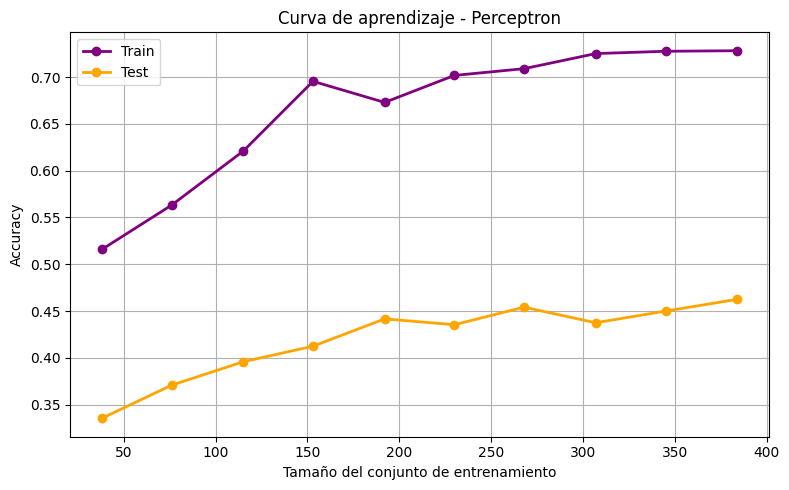

In [104]:
# Curva de aprendizaje
train_sizes_perceptron, train_scores_perceptron, test_scores_perceptron = learning_curve(
    pipe_perceptron_cv, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

train_mean_perceptron = train_scores_perceptron.mean(axis=1)
test_mean_perceptron = test_scores_perceptron.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_perceptron, train_mean_perceptron, 'o-', label='Train', color='purple', linewidth=2)
plt.plot(train_sizes_perceptron, test_mean_perceptron, 'o-', label='Test', color='orange', linewidth=2)
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curva de aprendizaje - Perceptron')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### 4.10.6 Curvas ROC-AUC

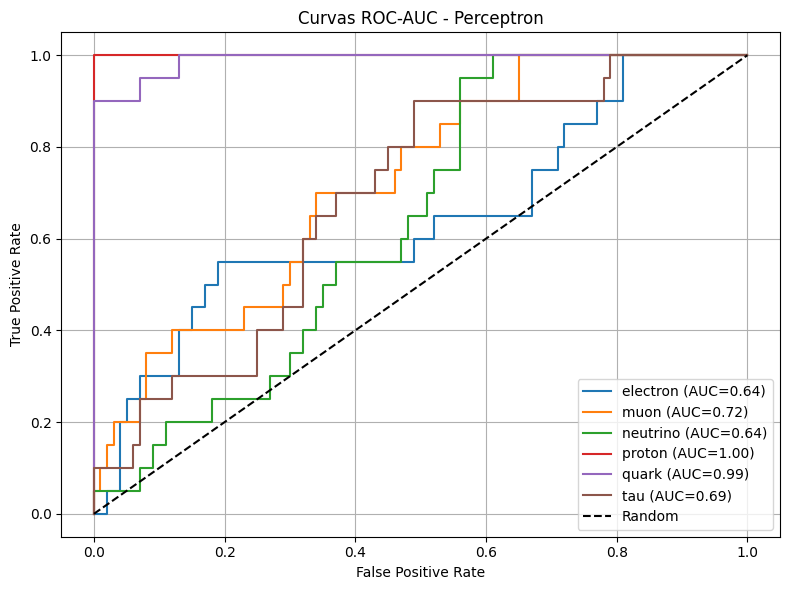

In [105]:
# Curvas ROC-AUC - Perceptron
# Nota: Perceptron usa decision_function en lugar de predict_proba
y_test_bin_perceptron = label_binarize(y_test, classes=pipe_perceptron.classes_)
y_score_perceptron = pipe_perceptron.decision_function(X_test)

fpr_perceptron = dict()
tpr_perceptron = dict()
roc_auc_perceptron = dict()

for i in range(len(pipe_perceptron.classes_)):
    fpr_perceptron[i], tpr_perceptron[i], _ = roc_curve(y_test_bin_perceptron[:, i], y_score_perceptron[:, i])
    roc_auc_perceptron[i] = auc(fpr_perceptron[i], tpr_perceptron[i])

plt.figure(figsize=(8, 6))
for i, clase in enumerate(pipe_perceptron.classes_):
    plt.plot(fpr_perceptron[i], tpr_perceptron[i], label=f'{clase} (AUC={roc_auc_perceptron[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC-AUC - Perceptron')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.10.7 Análisis de overfitting 


Evaluación de Overfitting: Perceptron
Accuracy Train: 0.7375 | Test: 0.4833 | Diff: 0.2542
F1-Score Train: 0.7313 | Test: 0.4405 | Diff: 0.2908
OVERFITTING (diferencia >10%)


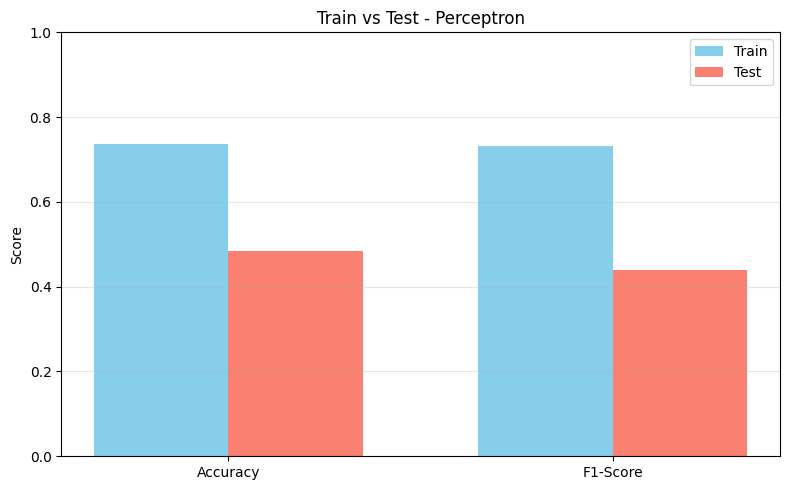

In [106]:
# Análisis de overfitting
evaluar_overfitting(pipe_perceptron, X_train, X_test, y_train, y_test, "Perceptron")

---
### 4.11 MLP (Red Neuronal - Opcional)

#### 4.11.1 Hiperparámetros manuales

In [107]:
mlp_hidden_layers = (100, 50)  # 2 capas ocultas: 100 y 50 neuronas
mlp_alpha = 0.0001  # Regularización L2
mlp_max_iter = 500
mlp_learning_rate = 'adaptive'

#### 4.11.2 Pipeline + Entrenamiento

In [108]:
# Pipeline y entrenamiento de MLP
from sklearn.neural_network import MLPClassifier

pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', MLPClassifier(hidden_layer_sizes=mlp_hidden_layers, alpha=mlp_alpha, 
                          max_iter=mlp_max_iter, learning_rate=mlp_learning_rate, random_state=42))
])
pipe_mlp.fit(X_train, y_train)

# Validación cruzada (CV)
pipe_mlp_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.50)),
    ('clf', MLPClassifier(hidden_layer_sizes=mlp_hidden_layers, alpha=mlp_alpha, 
                          max_iter=mlp_max_iter, learning_rate=mlp_learning_rate, random_state=42))
])
cv_scores_mlp = cross_val_score(pipe_mlp_cv, X_train, y_train, cv=5, scoring='accuracy')
print(f'Accuracy CV (5 folds): {cv_scores_mlp.mean():.4f}')

Accuracy CV (5 folds): 0.5271


#### 4.11.3 Evaluación y métricas

In [109]:
# Evaluación completa de MLP
y_pred_mlp = pipe_mlp.predict(X_test)
y_train_pred_mlp = pipe_mlp.predict(X_train)

acc_test_mlp = accuracy_score(y_test, y_pred_mlp)
acc_train_mlp = accuracy_score(y_train, y_train_pred_mlp)

print(f'Accuracy en train: {acc_train_mlp:.4f}')
print(f'Accuracy en test: {acc_test_mlp:.4f}')
print(f'Accuracy CV (5 folds): {cv_scores_mlp.mean():.4f}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_mlp))

Accuracy en train: 1.0000
Accuracy en test: 0.5833
Accuracy CV (5 folds): 0.5271

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.35      0.30      0.32        20
        muon       0.48      0.55      0.51        20
    neutrino       0.41      0.45      0.43        20
      proton       0.89      0.80      0.84        20
       quark       0.87      1.00      0.93        20
         tau       0.47      0.40      0.43        20

    accuracy                           0.58       120
   macro avg       0.58      0.58      0.58       120
weighted avg       0.58      0.58      0.58       120



#### 4.11.4 Matrices de confusión

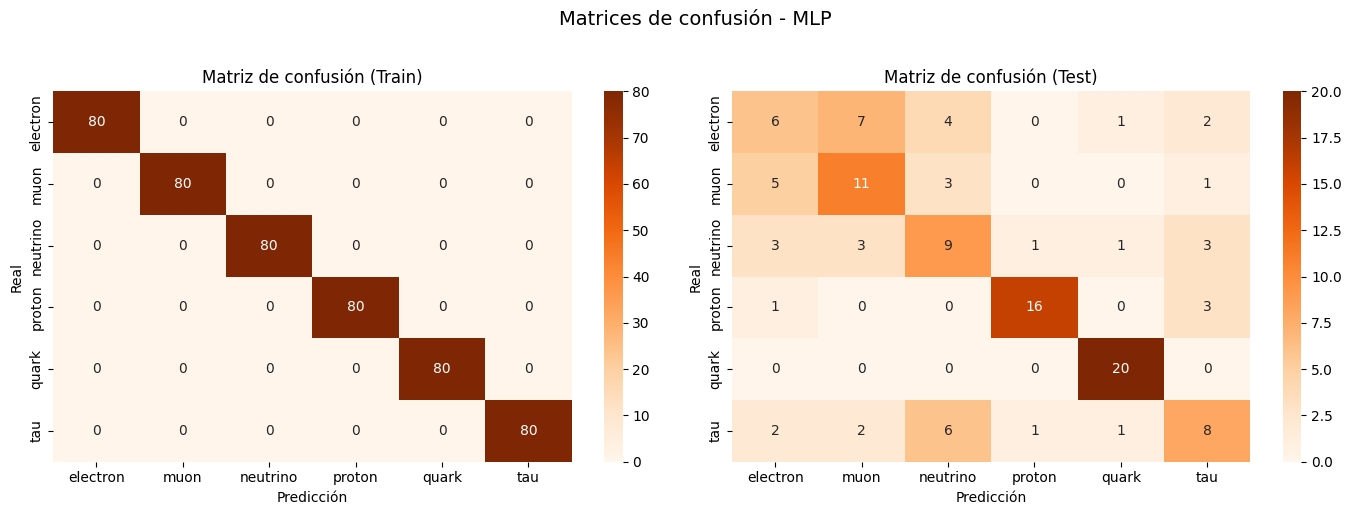

In [110]:
# Matriz de confusión - MLP (Train y Test juntas)
cm_train_mlp = confusion_matrix(y_train, y_train_pred_mlp, labels=pipe_mlp.classes_)
cm_test_mlp = confusion_matrix(y_test, y_pred_mlp, labels=pipe_mlp.classes_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión Train
sns.heatmap(cm_train_mlp, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=pipe_mlp.classes_, yticklabels=pipe_mlp.classes_, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de confusión (Train)')

# Matriz de confusión Test
sns.heatmap(cm_test_mlp, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=pipe_mlp.classes_, yticklabels=pipe_mlp.classes_, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de confusión (Test)')

plt.suptitle('Matrices de confusión - MLP', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 4.11.5 Curva de aprendizaje

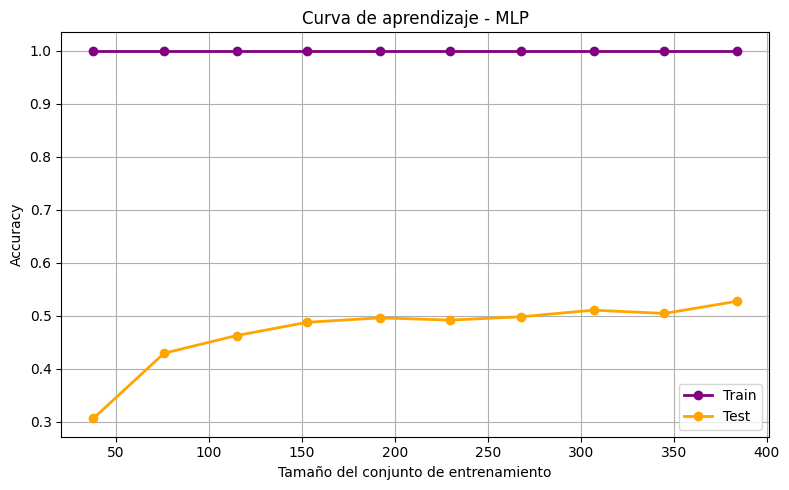

In [111]:
# Curva de aprendizaje - MLP
train_sizes_mlp, train_scores_mlp, test_scores_mlp = learning_curve(
    pipe_mlp_cv, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy'
)

train_mean_mlp = train_scores_mlp.mean(axis=1)
test_mean_mlp = test_scores_mlp.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_mlp, train_mean_mlp, 'o-', label='Train', color='purple', linewidth=2)
plt.plot(train_sizes_mlp, test_mean_mlp, 'o-', label='Test', color='orange', linewidth=2)
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curva de aprendizaje - MLP')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.11.6 Curvas ROC-AUC

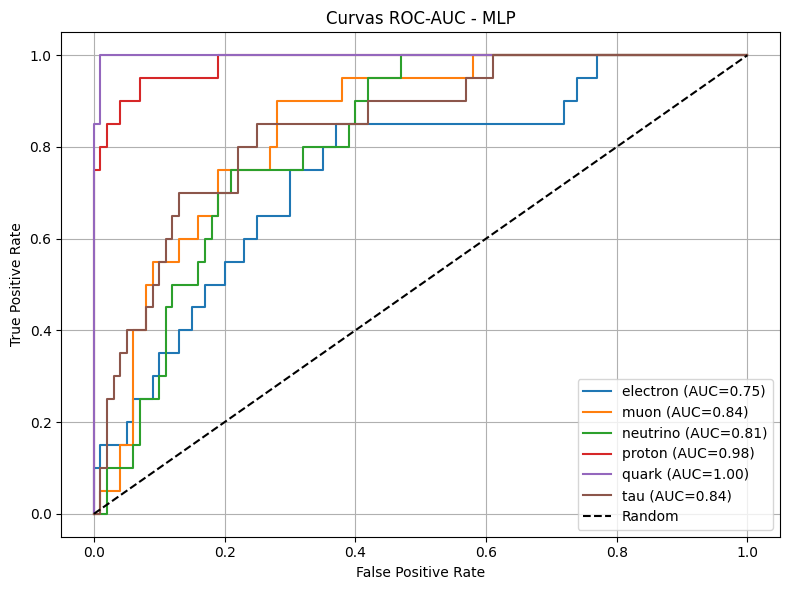

In [112]:
# Curvas ROC-AUC - MLP
y_test_bin_mlp = label_binarize(y_test, classes=pipe_mlp.classes_)
y_score_mlp = pipe_mlp.predict_proba(X_test)

fpr_mlp = dict()
tpr_mlp = dict()
roc_auc_mlp = dict()

for i in range(len(pipe_mlp.classes_)):
    fpr_mlp[i], tpr_mlp[i], _ = roc_curve(y_test_bin_mlp[:, i], y_score_mlp[:, i])
    roc_auc_mlp[i] = auc(fpr_mlp[i], tpr_mlp[i])

plt.figure(figsize=(8, 6))
for i, clase in enumerate(pipe_mlp.classes_):
    plt.plot(fpr_mlp[i], tpr_mlp[i], label=f'{clase} (AUC={roc_auc_mlp[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC-AUC - MLP')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.11.7 Análisis overfitting


Evaluación de Overfitting: MLP
Accuracy Train: 1.0000 | Test: 0.5833 | Diff: 0.4167
F1-Score Train: 1.0000 | Test: 0.5782 | Diff: 0.4218
OVERFITTING (diferencia >10%)


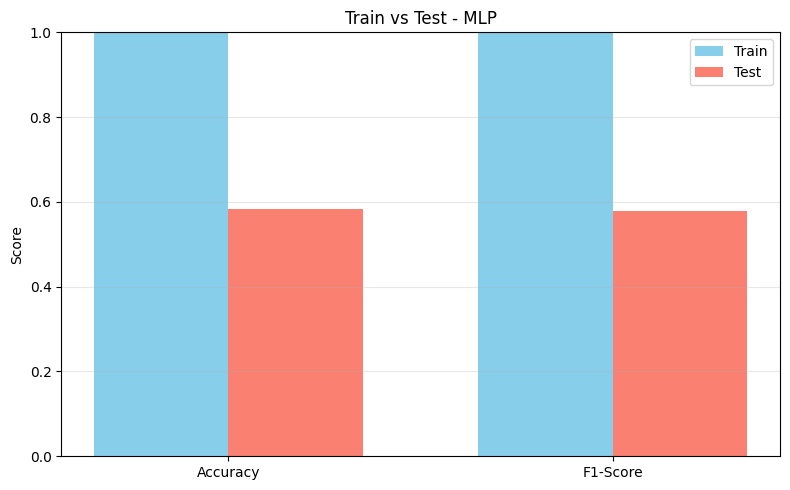

In [113]:
# Análisis de overfitting - MLP
evaluar_overfitting(pipe_mlp, X_train, X_test, y_train, y_test, "MLP")

---
## 5. COMPARACIÓN FINAL DE MODELOS

### 5.1 Tabla comparativa de todos los modelos

In [114]:
# Recopilar resultados de todos los modelos
resultados_modelos = []

# 1. Regresión Logística
y_pred_logreg = pipe_logreg.predict(X_test)
y_train_pred_logreg = pipe_logreg.predict(X_train)
resultados_modelos.append({
    'Modelo': 'Regresión Logística',
    'Acc Train': accuracy_score(y_train, y_train_pred_logreg),
    'Acc Test': accuracy_score(y_test, y_pred_logreg),
    'Acc CV': cv_scores.mean(),
    'Precision': precision_score(y_test, y_pred_logreg, average='weighted'),
    'Recall': recall_score(y_test, y_pred_logreg, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_logreg, average='weighted')
})

# 2. SVM RBF
y_pred_svm = pipe_svm.predict(X_test)
y_train_pred_svm = pipe_svm.predict(X_train)
resultados_modelos.append({
    'Modelo': 'SVM RBF',
    'Acc Train': accuracy_score(y_train, y_train_pred_svm),
    'Acc Test': accuracy_score(y_test, y_pred_svm),
    'Acc CV': cv_scores_svm.mean(),
    'Precision': precision_score(y_test, y_pred_svm, average='weighted'),
    'Recall': recall_score(y_test, y_pred_svm, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_svm, average='weighted')
})

# 3. K-Nearest Neighbors
y_pred_knn = pipe_knn.predict(X_test)
y_train_pred_knn = pipe_knn.predict(X_train)
resultados_modelos.append({
    'Modelo': 'K-Nearest Neighbors',
    'Acc Train': accuracy_score(y_train, y_train_pred_knn),
    'Acc Test': accuracy_score(y_test, y_pred_knn),
    'Acc CV': cv_scores_knn.mean(),
    'Precision': precision_score(y_test, y_pred_knn, average='weighted'),
    'Recall': recall_score(y_test, y_pred_knn, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_knn, average='weighted')
})

# 4. Naive Bayes
y_pred_nb = pipe_nb.predict(X_test)
y_train_pred_nb = pipe_nb.predict(X_train)
resultados_modelos.append({
    'Modelo': 'Naive Bayes',
    'Acc Train': accuracy_score(y_train, y_train_pred_nb),
    'Acc Test': accuracy_score(y_test, y_pred_nb),
    'Acc CV': cv_scores_nb.mean(),
    'Precision': precision_score(y_test, y_pred_nb, average='weighted'),
    'Recall': recall_score(y_test, y_pred_nb, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_nb, average='weighted')
})

# 5. Decision Tree
y_pred_dt = pipe_dt.predict(X_test)
y_train_pred_dt = pipe_dt.predict(X_train)
resultados_modelos.append({
    'Modelo': 'Decision Tree',
    'Acc Train': accuracy_score(y_train, y_train_pred_dt),
    'Acc Test': accuracy_score(y_test, y_pred_dt),
    'Acc CV': cv_scores.mean(),
    'Precision': precision_score(y_test, y_pred_dt, average='weighted'),
    'Recall': recall_score(y_test, y_pred_dt, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_dt, average='weighted')
})

# 6. Random Forest
y_pred_rf = pipe_rf.predict(X_test)
y_train_pred_rf = pipe_rf.predict(X_train)
resultados_modelos.append({
    'Modelo': 'Random Forest',
    'Acc Train': accuracy_score(y_train, y_train_pred_rf),
    'Acc Test': accuracy_score(y_test, y_pred_rf),
    'Acc CV': cv_scores_rf.mean(),
    'Precision': precision_score(y_test, y_pred_rf, average='weighted'),
    'Recall': recall_score(y_test, y_pred_rf, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_rf, average='weighted')
})

# 7. Perceptron
y_pred_perceptron = pipe_perceptron.predict(X_test)
y_train_pred_perceptron = pipe_perceptron.predict(X_train)
resultados_modelos.append({
    'Modelo': 'Perceptron',
    'Acc Train': accuracy_score(y_train, y_train_pred_perceptron),
    'Acc Test': accuracy_score(y_test, y_pred_perceptron),
    'Acc CV': cv_scores_perceptron.mean(),
    'Precision': precision_score(y_test, y_pred_perceptron, average='weighted'),
    'Recall': recall_score(y_test, y_pred_perceptron, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_perceptron, average='weighted')
})

# 8. MLP
y_pred_mlp = pipe_mlp.predict(X_test)
y_train_pred_mlp = pipe_mlp.predict(X_train)
resultados_modelos.append({
    'Modelo': 'MLP',
    'Acc Train': accuracy_score(y_train, y_train_pred_mlp),
    'Acc Test': accuracy_score(y_test, y_pred_mlp),
    'Acc CV': cv_scores_mlp.mean(),
    'Precision': precision_score(y_test, y_pred_mlp, average='weighted'),
    'Recall': recall_score(y_test, y_pred_mlp, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_mlp, average='weighted')
})

# Crear DataFrame
df_resultados = pd.DataFrame(resultados_modelos)

# Calcular diferencia Train-Test (overfitting)
df_resultados['Diff Train-Test'] = df_resultados['Acc Train'] - df_resultados['Acc Test']

# Ordenar por Accuracy Test (descendente)
df_resultados = df_resultados.sort_values('Acc Test', ascending=False).reset_index(drop=True)

# Mostrar tabla
print("\n" + "="*100)
print("COMPARACIÓN FINAL DE MODELOS")
print("="*100)
print(df_resultados.to_string(index=False))
print("="*100)

# Análisis rápido
print(f"\n📊 RESUMEN:")
print(f"  Mejor Accuracy Test: {df_resultados.iloc[0]['Modelo']} ({df_resultados.iloc[0]['Acc Test']:.4f})")
print(f"  Mejor F1-Score: {df_resultados.loc[df_resultados['F1-Score'].idxmax(), 'Modelo']} ({df_resultados['F1-Score'].max():.4f})")
print(f"  Menor Overfitting: {df_resultados.loc[df_resultados['Diff Train-Test'].idxmin(), 'Modelo']} ({df_resultados['Diff Train-Test'].min():.4f})")
print(f"  Mayor Overfitting: {df_resultados.loc[df_resultados['Diff Train-Test'].idxmax(), 'Modelo']} ({df_resultados['Diff Train-Test'].max():.4f})")

c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,


COMPARACIÓN FINAL DE MODELOS
             Modelo  Acc Train  Acc Test   Acc CV  Precision   Recall  F1-Score  Diff Train-Test
                MLP   1.000000  0.583333 0.527083   0.578223 0.583333  0.578216         0.416667
Regresión Logística   0.912500  0.575000 0.475000   0.554286 0.575000  0.559054         0.337500
      Random Forest   0.997917  0.566667 0.508333   0.595830 0.566667  0.541752         0.431250
         Perceptron   0.737500  0.483333 0.462500   0.431697 0.483333  0.440523         0.254167
      Decision Tree   0.897917  0.475000 0.475000   0.488445 0.475000  0.472051         0.422917
            SVM RBF   1.000000  0.400000 0.391667   0.323632 0.400000  0.343509         0.600000
K-Nearest Neighbors   0.506250  0.308333 0.329167   0.212071 0.308333  0.224919         0.197917
        Naive Bayes   0.718750  0.183333 0.179167   0.279762 0.183333  0.081530         0.535417

📊 RESUMEN:
  Mejor Accuracy Test: MLP (0.5833)
  Mejor F1-Score: MLP (0.5782)
  Menor Overfittin

### 5.2 Gráfico de barras comparativo

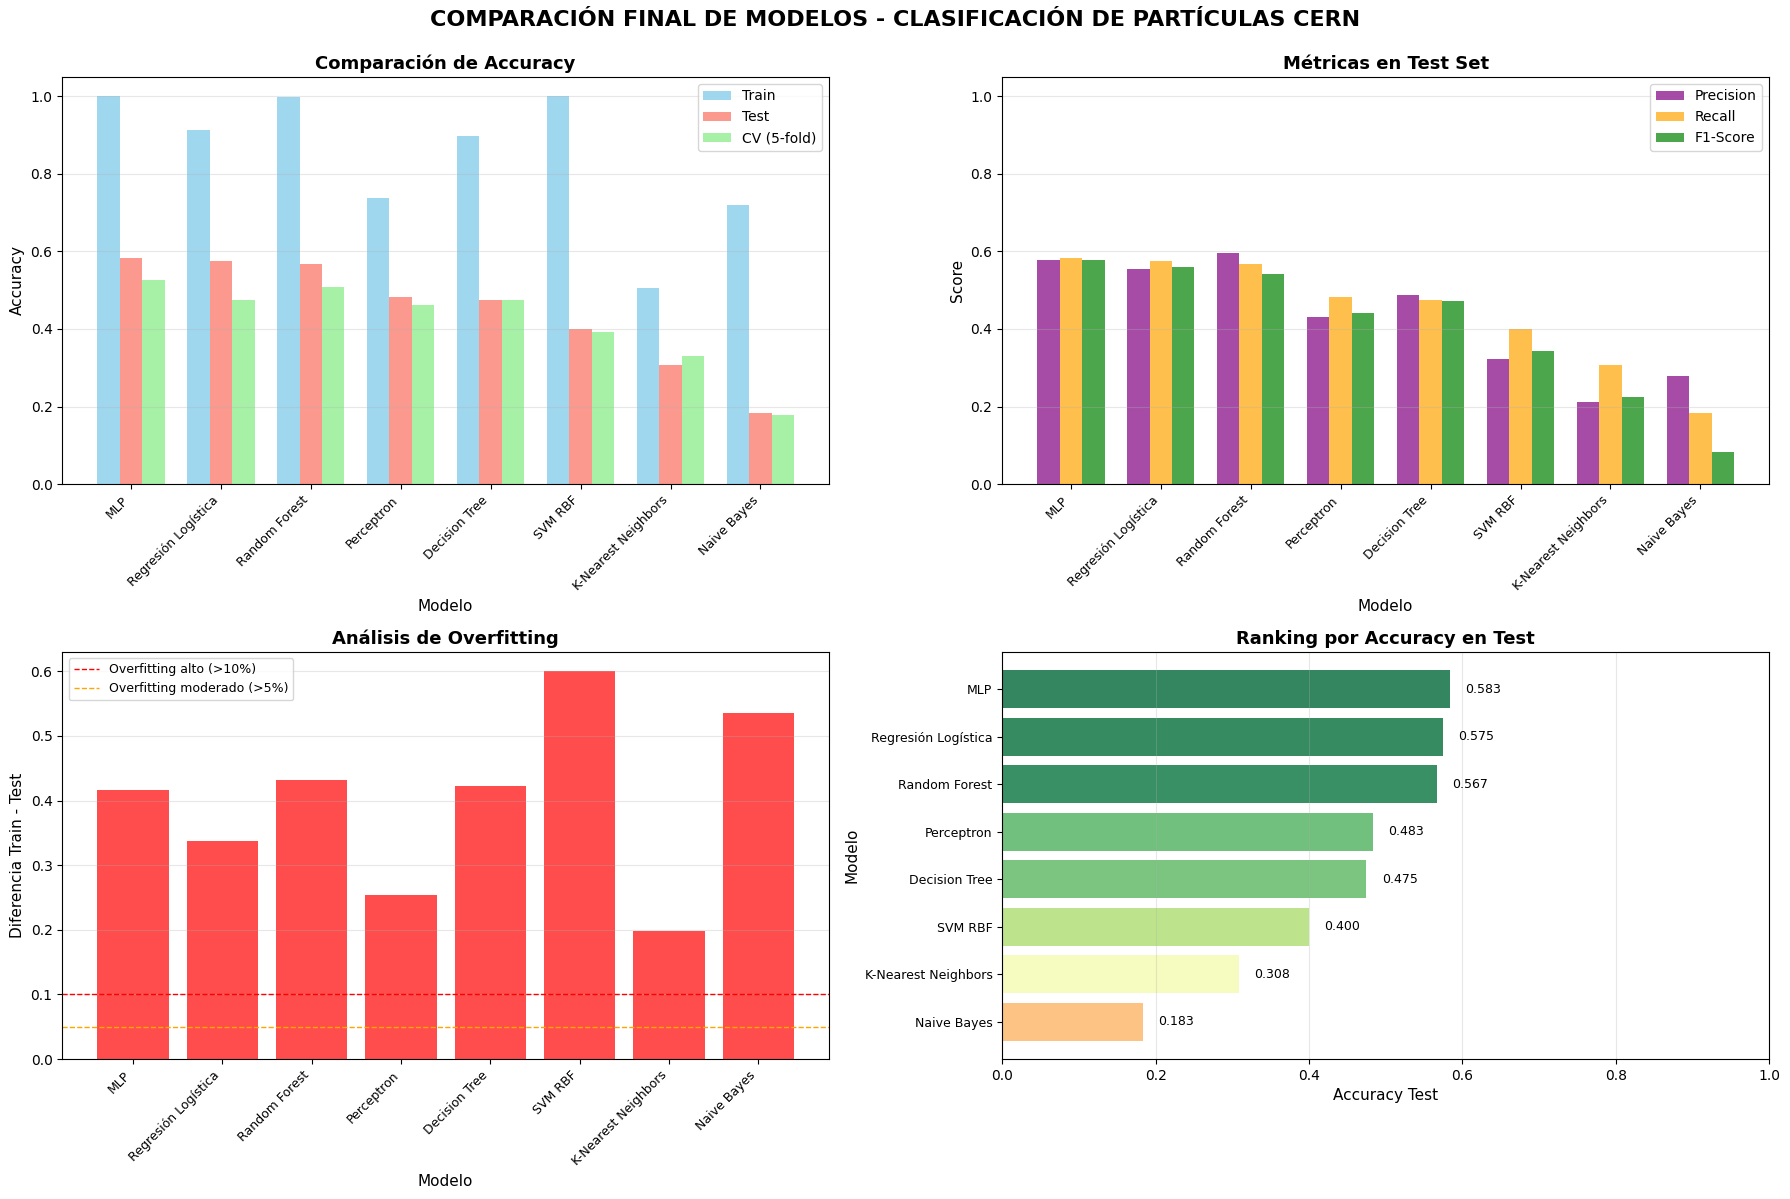


💡 Interpretación:
  - Verde: Buen rendimiento / Bajo overfitting
  - Naranja: Rendimiento moderado / Overfitting moderado
  - Rojo: Bajo rendimiento / Alto overfitting


In [115]:
# Gráfico comparativo de métricas
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Subplot 1: Accuracy (Train, Test, CV)
ax1 = axes[0, 0]
x_pos = np.arange(len(df_resultados))
width = 0.25

ax1.bar(x_pos - width, df_resultados['Acc Train'], width, label='Train', color='skyblue', alpha=0.8)
ax1.bar(x_pos, df_resultados['Acc Test'], width, label='Test', color='salmon', alpha=0.8)
ax1.bar(x_pos + width, df_resultados['Acc CV'], width, label='CV (5-fold)', color='lightgreen', alpha=0.8)

ax1.set_xlabel('Modelo', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Comparación de Accuracy', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_resultados['Modelo'], rotation=45, ha='right', fontsize=9)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.05])

# Subplot 2: Métricas Test (Precision, Recall, F1-Score)
ax2 = axes[0, 1]
width2 = 0.25

ax2.bar(x_pos - width2, df_resultados['Precision'], width2, label='Precision', color='purple', alpha=0.7)
ax2.bar(x_pos, df_resultados['Recall'], width2, label='Recall', color='orange', alpha=0.7)
ax2.bar(x_pos + width2, df_resultados['F1-Score'], width2, label='F1-Score', color='green', alpha=0.7)

ax2.set_xlabel('Modelo', fontsize=11)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Métricas en Test Set', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(df_resultados['Modelo'], rotation=45, ha='right', fontsize=9)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 1.05])

# Subplot 3: Overfitting (Diferencia Train-Test)
ax3 = axes[1, 0]
colors = ['red' if x > 0.1 else 'orange' if x > 0.05 else 'green' for x in df_resultados['Diff Train-Test']]
ax3.bar(x_pos, df_resultados['Diff Train-Test'], color=colors, alpha=0.7)
ax3.axhline(y=0.1, color='red', linestyle='--', linewidth=1, label='Overfitting alto (>10%)')
ax3.axhline(y=0.05, color='orange', linestyle='--', linewidth=1, label='Overfitting moderado (>5%)')

ax3.set_xlabel('Modelo', fontsize=11)
ax3.set_ylabel('Diferencia Train - Test', fontsize=11)
ax3.set_title('Análisis de Overfitting', fontsize=13, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(df_resultados['Modelo'], rotation=45, ha='right', fontsize=9)
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# Subplot 4: Ranking por Accuracy Test
ax4 = axes[1, 1]
df_sorted = df_resultados.sort_values('Acc Test', ascending=True)
colors_rank = plt.cm.RdYlGn(df_sorted['Acc Test'] / df_sorted['Acc Test'].max())

y_pos = np.arange(len(df_sorted))
ax4.barh(y_pos, df_sorted['Acc Test'], color=colors_rank, alpha=0.8)

ax4.set_xlabel('Accuracy Test', fontsize=11)
ax4.set_ylabel('Modelo', fontsize=11)
ax4.set_title('Ranking por Accuracy en Test', fontsize=13, fontweight='bold')
ax4.set_yticks(y_pos)
ax4.set_yticklabels(df_sorted['Modelo'], fontsize=9)
ax4.grid(axis='x', alpha=0.3)
ax4.set_xlim([0, 1.0])

# Añadir valores en las barras
for i, v in enumerate(df_sorted['Acc Test']):
    ax4.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('COMPARACIÓN FINAL DE MODELOS - CLASIFICACIÓN DE PARTÍCULAS CERN', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n💡 Interpretación:")
print("  - Verde: Buen rendimiento / Bajo overfitting")
print("  - Naranja: Rendimiento moderado / Overfitting moderado")
print("  - Rojo: Bajo rendimiento / Alto overfitting")

### 5.3 Mejor modelo

---
## 6. CLUSTERING (No Supervisado - Opcional)

### 6.1 K-Means

#### 6.1.1 Método del codo (Elbow Method)

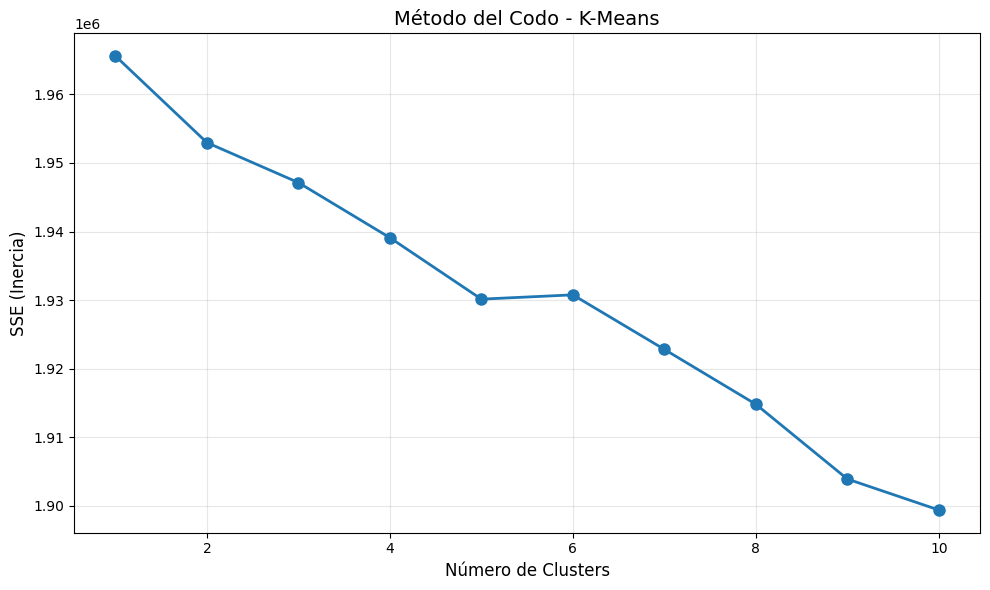

SSE para cada k: {1: 1965599.9999999993, 2: 1952971.5145918494, 3: 1947138.5921417938, 4: 1939100.8136796756, 5: 1930140.055778289, 6: 1930766.420665588, 7: 1922810.9776054476, 8: 1914805.3809668687, 9: 1903904.517662731, 10: 1899382.258719697}


In [116]:
# Método del codo para determinar el número óptimo de clusters
SSE = []
numClusters = list(range(1, 11))

for k in numClusters:
    kmeans_temp = KMeans(n_clusters=k, n_init=20, max_iter=300, random_state=42)
    kmeans_temp.fit(X_train_scaled)
    SSE.append(kmeans_temp.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(numClusters, SSE, marker="o", linewidth=2, markersize=8)
plt.xlabel('Número de Clusters', fontsize=12)
plt.ylabel('SSE (Inercia)', fontsize=12)
plt.title('Método del Codo - K-Means', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"SSE para cada k: {dict(zip(numClusters, SSE))}")

#### 6.1.2 Entrenamiento K-Means

In [117]:
# Entrenar K-Means con el número de clusters elegido (6 clases en el dataset)
n_clusters_kmeans = 6

kmeans = KMeans(n_clusters=n_clusters_kmeans, n_init=20, max_iter=300, random_state=42)
kmeans.fit(X_train_scaled)
kmeans_labels = kmeans.labels_

print(f"Número de clusters: {n_clusters_kmeans}")
print(f"Inercia (SSE): {kmeans.inertia_:.2f}")
print(f"Número de iteraciones: {kmeans.n_iter_}")
print(f"\nDistribución de puntos por cluster:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

Número de clusters: 6
Inercia (SSE): 1930766.42
Número de iteraciones: 7

Distribución de puntos por cluster:
0      1
1    234
2      2
3      7
4      1
5    235
Name: count, dtype: int64


### 6.2 Visualización con PCA 2D

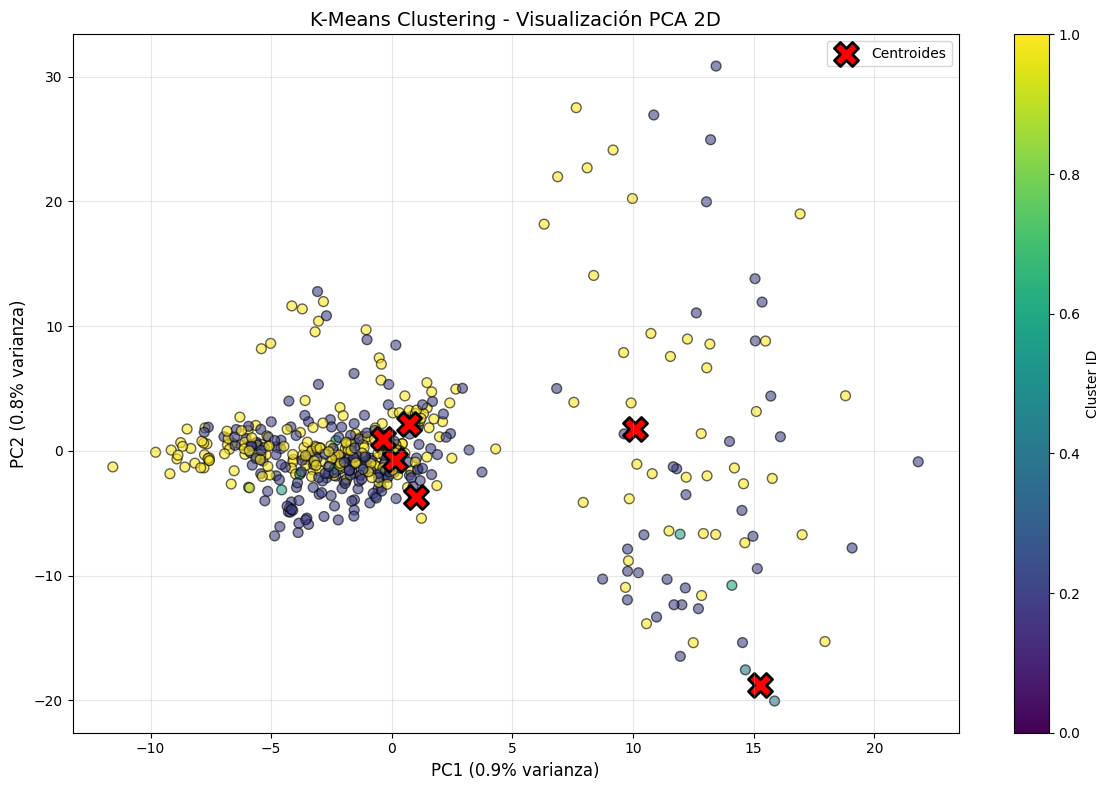

Varianza explicada por PC1: 0.94%
Varianza explicada por PC2: 0.76%
Varianza total explicada: 1.70%


In [118]:
# Reducción a 2D con PCA para visualización
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca2d = pca_2d.fit_transform(X_train_scaled)

# Transformar centroides a espacio PCA 2D
centroids = kmeans.cluster_centers_
centroids_pca2d = pca_2d.transform(centroids)

# Gráfico de clusters con centroides
plt.figure(figsize=(12, 8))
plt.scatter(X_train_pca2d[:, 0], X_train_pca2d[:, 1], c=kmeans_labels, 
            cmap='viridis', alpha=0.6, edgecolors='k', s=50)
plt.scatter(centroids_pca2d[:, 0], centroids_pca2d[:, 1], 
            s=300, c='red', marker='X', edgecolors='black', linewidths=2, label='Centroides')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
plt.title('K-Means Clustering - Visualización PCA 2D', fontsize=14)
plt.colorbar(label='Cluster ID')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Varianza explicada por PC1: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")
print(f"Varianza total explicada: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")

#### 6.2.1 Comparación con etiquetas reales

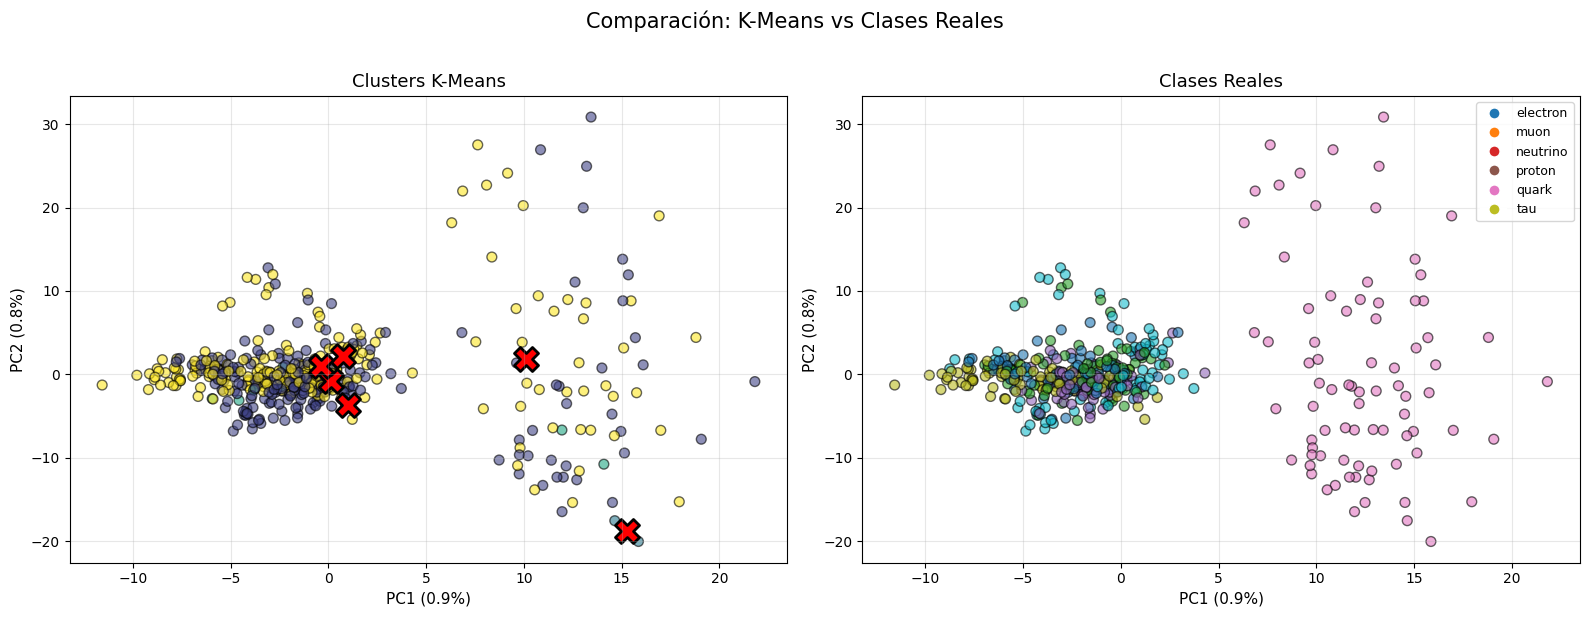

In [119]:
# Visualizar clusters vs clases reales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Clusters encontrados por K-Means
axes[0].scatter(X_train_pca2d[:, 0], X_train_pca2d[:, 1], c=kmeans_labels, 
                cmap='viridis', alpha=0.6, edgecolors='k', s=50)
axes[0].scatter(centroids_pca2d[:, 0], centroids_pca2d[:, 1], 
                s=300, c='red', marker='X', edgecolors='black', linewidths=2)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[0].set_title('Clusters K-Means', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Subplot 2: Clases reales
clases_unicas = sorted(list(set(y_train)))
y_train_numeric = [clases_unicas.index(label) for label in y_train]
scatter = axes[1].scatter(X_train_pca2d[:, 0], X_train_pca2d[:, 1], c=y_train_numeric, 
                          cmap='tab10', alpha=0.6, edgecolors='k', s=50)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[1].set_title('Clases Reales', fontsize=13)
axes[1].grid(True, alpha=0.3)

# Añadir leyenda con nombres de clases
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=plt.cm.tab10(i/len(clases_unicas)), 
                      markersize=8, label=clase) 
           for i, clase in enumerate(clases_unicas)]
axes[1].legend(handles=handles, loc='best', fontsize=9)

plt.suptitle('Comparación: K-Means vs Clases Reales', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

#### 6.2.2 Matriz de similitud (proximidad)

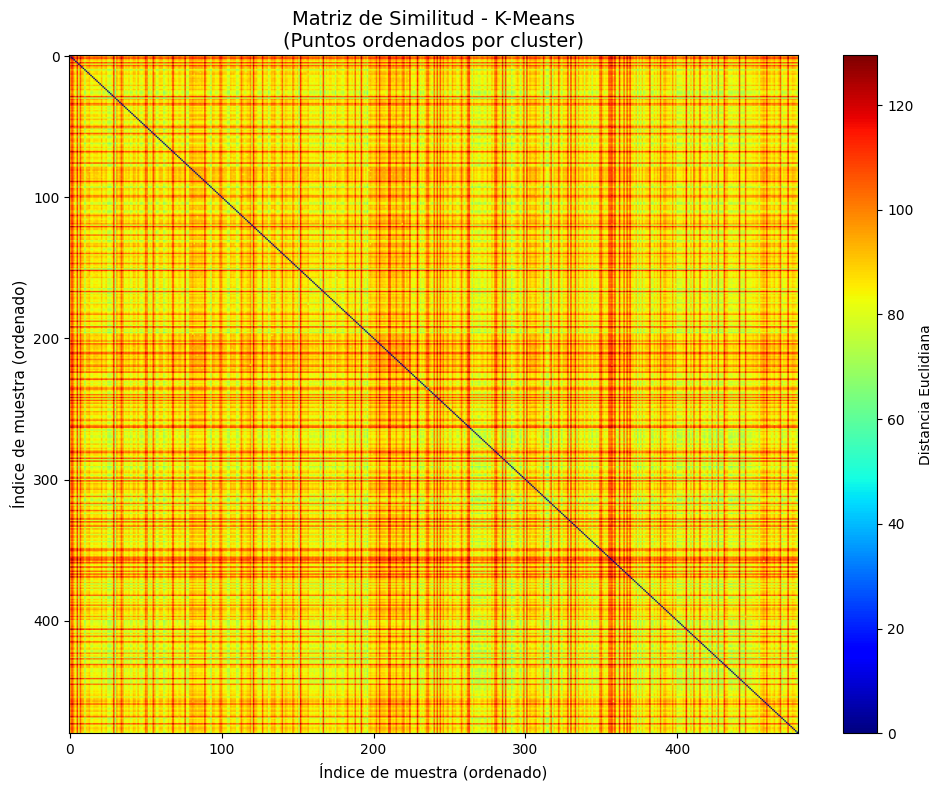

Interpretación: Bloques oscuros en la diagonal indican clusters bien definidos.
Bloques claros fuera de la diagonal indican separación entre clusters.


In [120]:
# Función para crear matriz de similitud
def sim_matrix(features, labels):
    useful_labels = labels >= 0
    # Ordenar datos por cluster
    indices = np.argsort(labels[useful_labels])
    sorted_features = features[useful_labels][indices]
    # Calcular distancias euclidiana
    d = euclidean_distances(sorted_features, sorted_features)
    return d

# Crear matriz de similitud
dist_matrix = sim_matrix(X_train_scaled, kmeans_labels)

# Visualizar matriz
plt.figure(figsize=(10, 8))
im = plt.imshow(dist_matrix, cmap="jet", aspect='auto')
plt.colorbar(im, label='Distancia Euclidiana')
plt.title('Matriz de Similitud - K-Means\n(Puntos ordenados por cluster)', fontsize=14)
plt.xlabel('Índice de muestra (ordenado)', fontsize=11)
plt.ylabel('Índice de muestra (ordenado)', fontsize=11)
plt.tight_layout()
plt.show()

print("Interpretación: Bloques oscuros en la diagonal indican clusters bien definidos.")
print("Bloques claros fuera de la diagonal indican separación entre clusters.")

#### 6.2.3 Silhouette Score


EVALUACIÓN DE CLUSTERING - K-MEANS
Silhouette Score: -0.0092

Interpretación del Silhouette Score:
  → Pobre estructura de clustering (<0.25)

Nota: Valores cercanos a 1 indican clusters bien separados.
      Valores cercanos a 0 indican solapamiento de clusters.
      Valores negativos indican mala asignación.


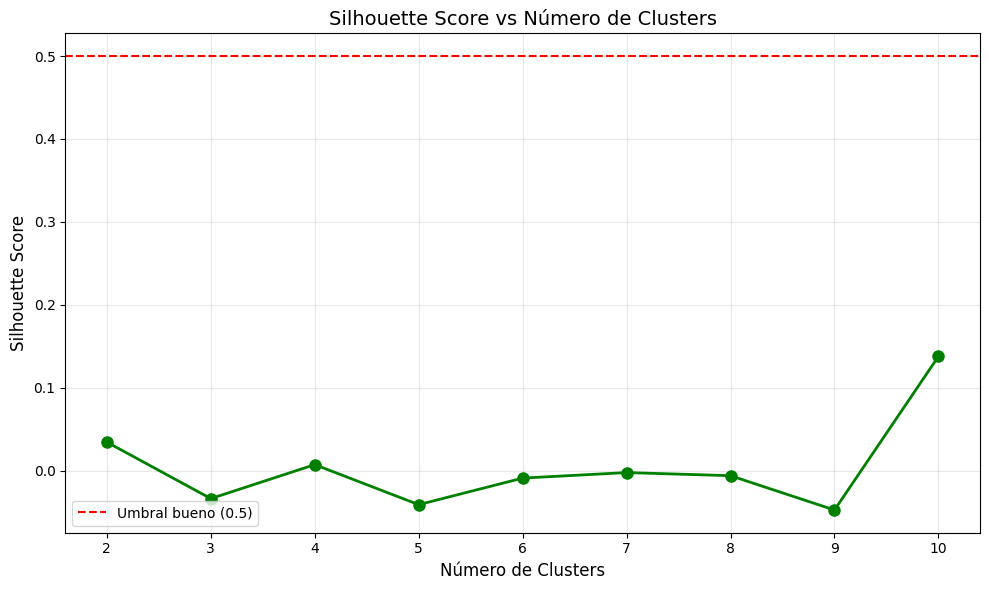


Mejor Silhouette Score: 0.1376 con k=10


In [121]:
# Calcular Silhouette Score
silhouette_avg = silhouette_score(X_train_scaled, kmeans_labels)

print(f"\n{'='*60}")
print(f"EVALUACIÓN DE CLUSTERING - K-MEANS")
print(f"{'='*60}")
print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"\nInterpretación del Silhouette Score:")
if silhouette_avg > 0.7:
    print("  → Excelente estructura de clustering (>0.7)")
elif silhouette_avg > 0.5:
    print("  → Buena estructura de clustering (0.5-0.7)")
elif silhouette_avg > 0.25:
    print("  → Estructura débil de clustering (0.25-0.5)")
else:
    print("  → Pobre estructura de clustering (<0.25)")
print(f"\nNota: Valores cercanos a 1 indican clusters bien separados.")
print(f"      Valores cercanos a 0 indican solapamiento de clusters.")
print(f"      Valores negativos indican mala asignación.")
print(f"{'='*60}")

# Silhouette Score por diferentes números de clusters
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, n_init=20, max_iter=300, random_state=42)
    labels_temp = kmeans_temp.fit_predict(X_train_scaled)
    score = silhouette_score(X_train_scaled, labels_temp)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(list(k_range), silhouette_scores, marker='o', linewidth=2, markersize=8, color='green')
plt.xlabel('Número de Clusters', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs Número de Clusters', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='r', linestyle='--', label='Umbral bueno (0.5)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nMejor Silhouette Score: {max(silhouette_scores):.4f} con k={list(k_range)[silhouette_scores.index(max(silhouette_scores))]}")

### 6.3 DBSCAN (opcional)

#### 6.3.1 Estimación de eps usando el método de la rodilla

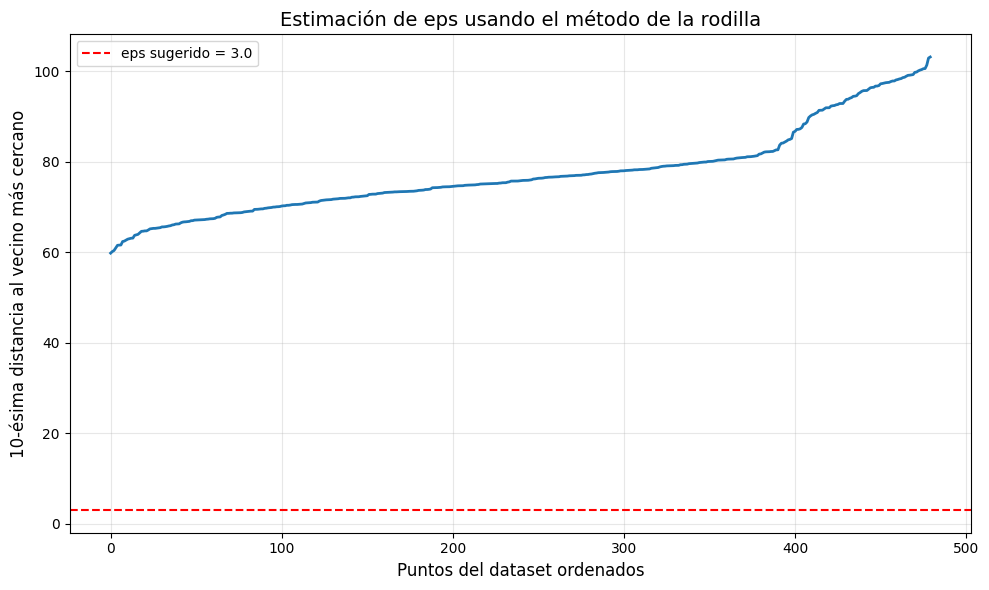

Distancia promedio: 77.4536
Distancia mediana: 75.8340
Percentil 90: 93.8698

Sugerencia: eps entre 80.47 y 97.59


In [122]:
# Método de la rodilla para estimar eps
N = 10  # número de vecinos
nbrs = NearestNeighbors(n_neighbors=N).fit(X_train_scaled)
distances, indices = nbrs.kneighbors(X_train_scaled)

distances = np.sort(distances, axis=0)
distances_k = distances[:, N-1]

plt.figure(figsize=(10, 6))
plt.plot(distances_k, linewidth=2)
plt.axhline(y=3.0, color='r', linestyle='--', label='eps sugerido = 3.0')
plt.xlabel('Puntos del dataset ordenados', fontsize=12)
plt.ylabel(f'{N}-ésima distancia al vecino más cercano', fontsize=12)
plt.title('Estimación de eps usando el método de la rodilla', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Distancia promedio: {distances_k.mean():.4f}")
print(f"Distancia mediana: {np.median(distances_k):.4f}")
print(f"Percentil 90: {np.percentile(distances_k, 90):.4f}")
print(f"\nSugerencia: eps entre {np.percentile(distances_k, 75):.2f} y {np.percentile(distances_k, 95):.2f}")

#### 6.3.2 Entrenamiento DBSCAN

In [123]:
# DBSCAN con parámetros estimados
eps = 3.0
min_samples = 10

dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit(X_train_scaled)
dbscan_labels = dbscan.labels_

# Estadísticas
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\n{'='*60}")
print(f"DBSCAN RESULTADOS")
print(f"{'='*60}")
print(f"eps: {eps}")
print(f"min_samples: {min_samples}")
print(f"Número de clusters encontrados: {n_clusters}")
print(f"Número de puntos de ruido: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
print(f"\nDistribución de puntos por cluster:")
print(pd.Series(dbscan_labels).value_counts().sort_index())
print(f"{'='*60}")


DBSCAN RESULTADOS
eps: 3.0
min_samples: 10
Número de clusters encontrados: 0
Número de puntos de ruido: 480 (100.0%)

Distribución de puntos por cluster:
-1    480
Name: count, dtype: int64


#### 6.3.3 Visualización DBSCAN

#### 6.3.4 Silhouette Score DBSCAN

In [124]:
# Silhouette Score para DBSCAN (excluyendo ruido)
if n_clusters > 1:
    filter_label = dbscan_labels >= 0
    if filter_label.sum() > 0:
        silhouette_dbscan = silhouette_score(X_train_scaled[filter_label], dbscan_labels[filter_label])
        print(f"\nSilhouette Score DBSCAN (sin ruido): {silhouette_dbscan:.4f}")
        
        if silhouette_dbscan > 0.5:
            print("  → Buena estructura de clustering")
        elif silhouette_dbscan > 0.25:
            print("  → Estructura débil de clustering")
        else:
            print("  → Pobre estructura de clustering")
else:
    print(f"\nNo se puede calcular Silhouette Score: solo {n_clusters} cluster(s) encontrado(s)")
    print("Sugerencia: Ajustar eps o min_samples para encontrar más clusters")


No se puede calcular Silhouette Score: solo 0 cluster(s) encontrado(s)
Sugerencia: Ajustar eps o min_samples para encontrar más clusters


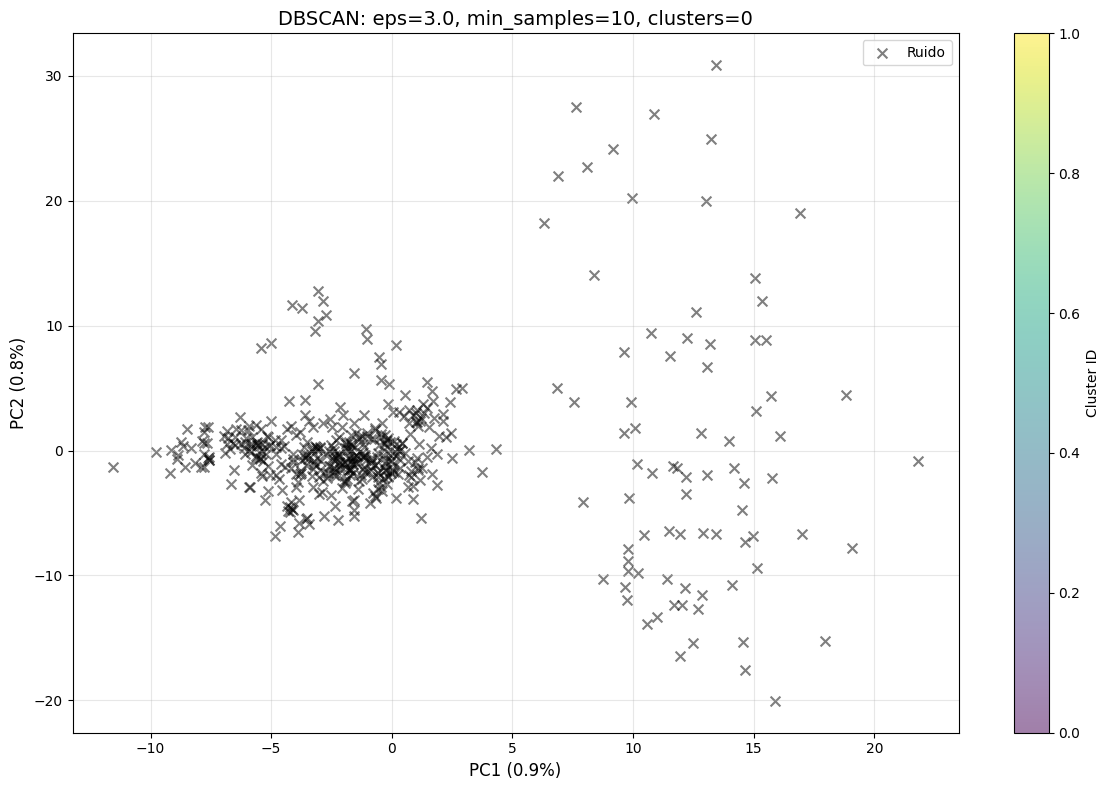

In [125]:
# Visualización DBSCAN en espacio PCA 2D
plt.figure(figsize=(12, 8))

# Puntos de ruido (-1) en negro
noise_mask = dbscan_labels == -1
plt.scatter(X_train_pca2d[noise_mask, 0], X_train_pca2d[noise_mask, 1], 
            c='black', marker='x', s=50, alpha=0.5, label='Ruido')

# Puntos de clusters
cluster_mask = dbscan_labels >= 0
if cluster_mask.sum() > 0:
    plt.scatter(X_train_pca2d[cluster_mask, 0], X_train_pca2d[cluster_mask, 1], 
                c=dbscan_labels[cluster_mask], cmap='viridis', 
                alpha=0.6, edgecolors='k', s=50)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title(f'DBSCAN: eps={eps}, min_samples={min_samples}, clusters={n_clusters}', fontsize=14)
plt.colorbar(label='Cluster ID')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 6.3.4 Silhouette Score DBSCAN

In [126]:
# Silhouette Score para DBSCAN (excluyendo ruido)
if n_clusters > 1:
    filter_label = dbscan_labels >= 0
    if filter_label.sum() > 0:
        silhouette_dbscan = silhouette_score(X_train_scaled[filter_label], dbscan_labels[filter_label])
        print(f"\nSilhouette Score DBSCAN (sin ruido): {silhouette_dbscan:.4f}")
        
        if silhouette_dbscan > 0.5:
            print("  → Buena estructura de clustering")
        elif silhouette_dbscan > 0.25:
            print("  → Estructura débil de clustering")
        else:
            print("  → Pobre estructura de clustering")
else:
    print(f"\nNo se puede calcular Silhouette Score: solo {n_clusters} cluster(s) encontrado(s)")
    print("Sugerencia: Ajustar eps o min_samples para encontrar más clusters")



No se puede calcular Silhouette Score: solo 0 cluster(s) encontrado(s)
Sugerencia: Ajustar eps o min_samples para encontrar más clusters


#### 6.2.2 Matriz de similitud (proximidad)

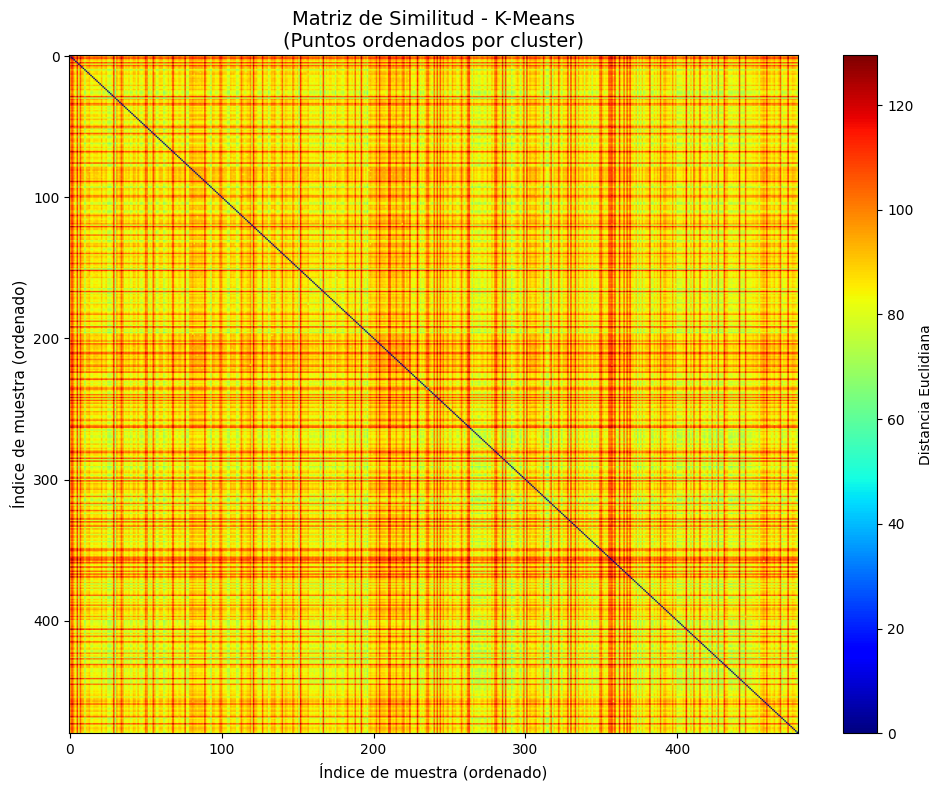

Interpretación: Bloques oscuros en la diagonal indican clusters bien definidos.
Bloques claros fuera de la diagonal indican separación entre clusters.


In [127]:
# Función para crear matriz de similitud
def sim_matrix(features, labels):
    useful_labels = labels >= 0
    # Ordenar datos por cluster
    indices = np.argsort(labels[useful_labels])
    sorted_features = features[useful_labels][indices]
    # Calcular distancias euclidiana
    d = euclidean_distances(sorted_features, sorted_features)
    return d

# Crear matriz de similitud
dist_matrix = sim_matrix(X_train_scaled, kmeans_labels)

# Visualizar matriz
plt.figure(figsize=(10, 8))
im = plt.imshow(dist_matrix, cmap="jet", aspect='auto')
plt.colorbar(im, label='Distancia Euclidiana')
plt.title('Matriz de Similitud - K-Means\n(Puntos ordenados por cluster)', fontsize=14)
plt.xlabel('Índice de muestra (ordenado)', fontsize=11)
plt.ylabel('Índice de muestra (ordenado)', fontsize=11)
plt.tight_layout()
plt.show()

print("Interpretación: Bloques oscuros en la diagonal indican clusters bien definidos.")
print("Bloques claros fuera de la diagonal indican separación entre clusters.")

#### 6.2.3 Silhouette Score


EVALUACIÓN DE CLUSTERING - K-MEANS
Silhouette Score: -0.0092

Interpretación del Silhouette Score:
  → Pobre estructura de clustering (<0.25)

Nota: Valores cercanos a 1 indican clusters bien separados.
      Valores cercanos a 0 indican solapamiento de clusters.
      Valores negativos indican mala asignación.


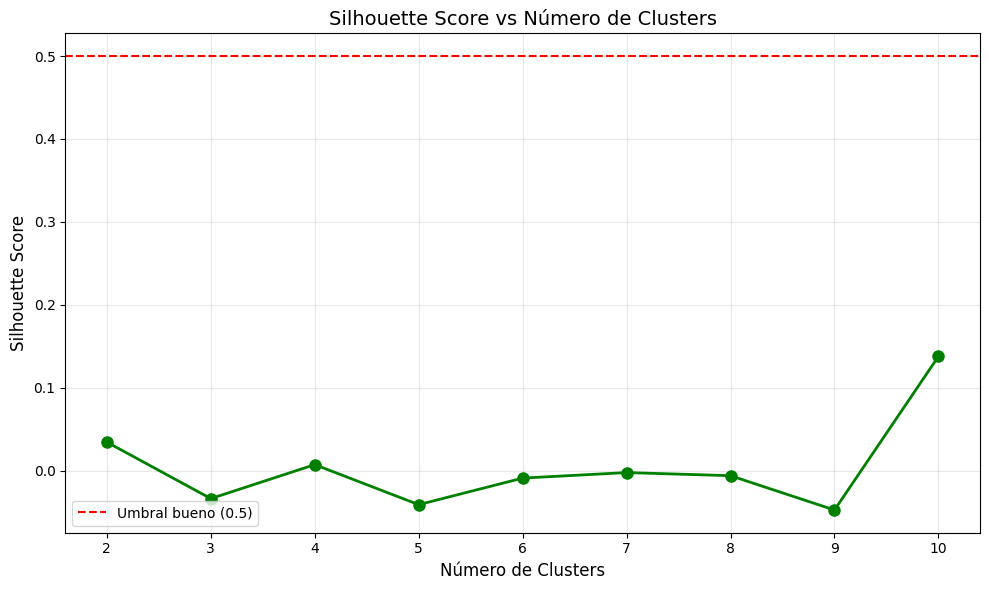


Mejor Silhouette Score: 0.1376 con k=10


In [128]:
# Calcular Silhouette Score
silhouette_avg = silhouette_score(X_train_scaled, kmeans_labels)

print(f"\n{'='*60}")
print(f"EVALUACIÓN DE CLUSTERING - K-MEANS")
print(f"{'='*60}")
print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"\nInterpretación del Silhouette Score:")
if silhouette_avg > 0.7:
    print("  → Excelente estructura de clustering (>0.7)")
elif silhouette_avg > 0.5:
    print("  → Buena estructura de clustering (0.5-0.7)")
elif silhouette_avg > 0.25:
    print("  → Estructura débil de clustering (0.25-0.5)")
else:
    print("  → Pobre estructura de clustering (<0.25)")
print(f"\nNota: Valores cercanos a 1 indican clusters bien separados.")
print(f"      Valores cercanos a 0 indican solapamiento de clusters.")
print(f"      Valores negativos indican mala asignación.")
print(f"{'='*60}")

# Silhouette Score por diferentes números de clusters
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, n_init=20, max_iter=300, random_state=42)
    labels_temp = kmeans_temp.fit_predict(X_train_scaled)
    score = silhouette_score(X_train_scaled, labels_temp)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(list(k_range), silhouette_scores, marker='o', linewidth=2, markersize=8, color='green')
plt.xlabel('Número de Clusters', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs Número de Clusters', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='r', linestyle='--', label='Umbral bueno (0.5)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nMejor Silhouette Score: {max(silhouette_scores):.4f} con k={list(k_range)[silhouette_scores.index(max(silhouette_scores))]}")


In [129]:
# Entrenar K-Means con el número de clusters elegido (6 clases en el dataset)
n_clusters_kmeans = 6

kmeans = KMeans(n_clusters=n_clusters_kmeans, n_init=20, max_iter=300, random_state=42)
kmeans.fit(X_train_scaled)
kmeans_labels = kmeans.labels_

print(f"Número de clusters: {n_clusters_kmeans}")
print(f"Inercia (SSE): {kmeans.inertia_:.2f}")
print(f"Número de iteraciones: {kmeans.n_iter_}")
print(f"\nDistribución de puntos por cluster:")
print(pd.Series(kmeans_labels).value_counts().sort_index())


Número de clusters: 6
Inercia (SSE): 1930766.42
Número de iteraciones: 7

Distribución de puntos por cluster:
0      1
1    234
2      2
3      7
4      1
5    235
Name: count, dtype: int64


### 6.2 Visualización con PCA 2D

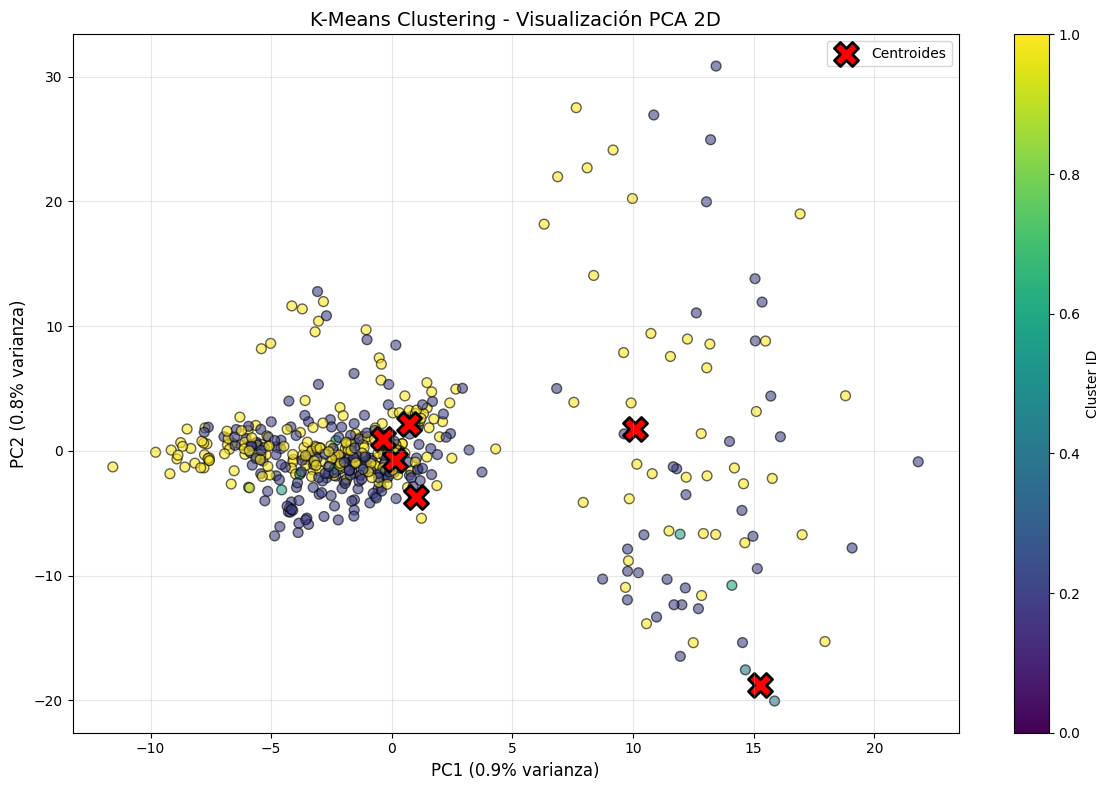

Varianza explicada por PC1: 0.94%
Varianza explicada por PC2: 0.76%
Varianza total explicada: 1.70%


In [130]:
# Reducción a 2D con PCA para visualización
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca2d = pca_2d.fit_transform(X_train_scaled)

# Transformar centroides a espacio PCA 2D
centroids = kmeans.cluster_centers_
centroids_pca2d = pca_2d.transform(centroids)

# Gráfico de clusters con centroides
plt.figure(figsize=(12, 8))
plt.scatter(X_train_pca2d[:, 0], X_train_pca2d[:, 1], c=kmeans_labels, 
            cmap='viridis', alpha=0.6, edgecolors='k', s=50)
plt.scatter(centroids_pca2d[:, 0], centroids_pca2d[:, 1], 
            s=300, c='red', marker='X', edgecolors='black', linewidths=2, label='Centroides')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
plt.title('K-Means Clustering - Visualización PCA 2D', fontsize=14)
plt.colorbar(label='Cluster ID')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Varianza explicada por PC1: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")
print(f"Varianza total explicada: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")

### 6.3 DBSCAN (opcional)

---
## 7. CONCLUSIONES

### 7.1 Resumen de resultados

- **Mejor modelo:** 
- **Accuracy:** 
- **Análisis de overfitting:** 
- **Recomendaciones:** 

### 7.2 Posibles mejoras

1. Aumentar dataset con data augmentation
2. Probar otros hiperparámetros con RandomizedSearchCV
3. Feature engineering adicional
4. Probar redes neuronales convolucionales (CNN)
5. Ensemble de mejores modelos